In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

# **Data Preparation**

In [3]:
df = pd.read_csv('../dataset/cmi_internet_cleaned.csv')

X = df.drop(columns="sii").values
y = np.array(df["sii"])


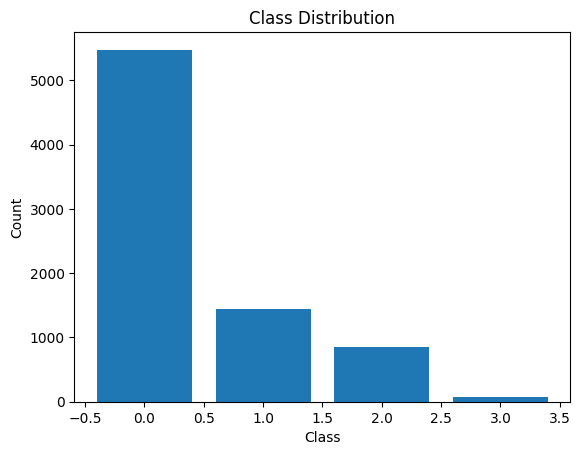

In [28]:
# plot class distribution
from collections import Counter
class_counts = Counter(y)
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()


# **Data Partitioning**

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# **Gradient Boosting**

## 4 classes, imbalanced

Starting Gradient Boosting Hyperparameter Tuning (Imbalanced Baseline)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.2}
Best Balanced Accuracy Score (CV): 0.3008

Evaluating Best Gradient Boosting Model on Test Set...


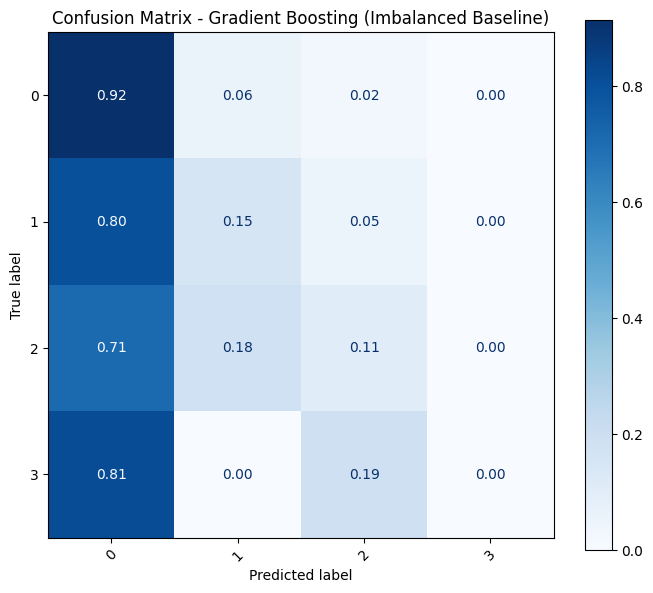

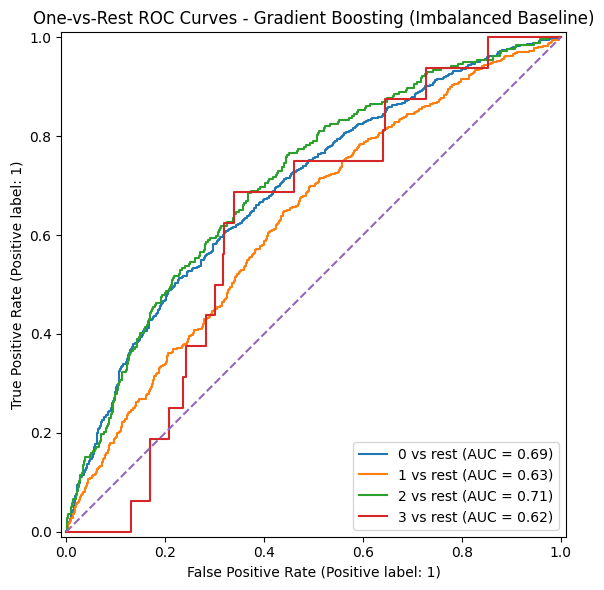

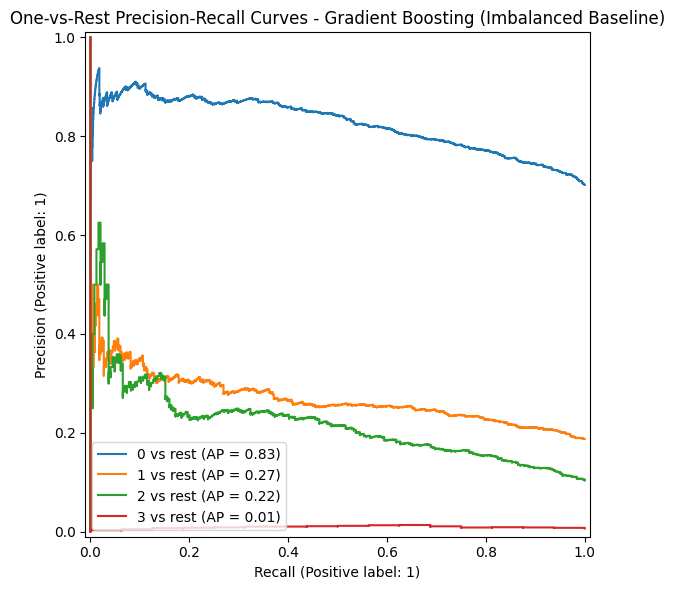


Classification report - Gradient Boosting (Imbalanced Baseline)


,precision,recall,f1-score,support
0,0.736585,0.915152,0.816216,1650.000000
1,0.317536,0.151584,0.205207,442.000000
2,0.288889,0.106557,0.155689,244.000000
3,0.000000,0.000000,0.000000,16.000000
accuracy,0.681548,0.681548,0.681548,0.681548
macro avg,0.335752,0.293323,0.294278,2352.000000
weighted avg,0.606380,0.681548,0.627316,2352.000000


In [5]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from evaluate_classifier import evaluate_classifier

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_gb = {
    # Numero di alberi sequenziali (round di boosting)
    'n_estimators': [50, 100, 200, 300],
    
    # Shrinkage: riduce il contributo di ogni albero per evitare overfitting
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    
    # Massima profondità di ogni singolo albero
    'max_depth': [3, 4, 5, 7],
    
    # Numero minimo di campioni richiesti per dividere un nodo interno
    'min_samples_split': [2, 5, 10],
    
    # Numero minimo di campioni richiesti in un nodo foglia
    'min_samples_leaf': [1, 2, 4],
    
    # Percentuale di feature da considerare per ogni split
    'max_features': ['sqrt', 'log2', None]
}

# Modello base
gb_base = GradientBoostingClassifier(random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Gradient Boosting Hyperparameter Tuning (Imbalanced Baseline)...")

random_search_gb = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist_gb,
    n_iter=40,                     # 40 combinazioni casuali nello spazio dei parametri
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizziamo comunque per la balanced accuracy
    n_jobs=-1,                     # Sfrutta tutti i core della CPU disponibili
    random_state=42,
    verbose=1
)

# Eseguiamo il fit sui dati originali sbilanciati a 3 classi
random_search_gb.fit(X_train, y_train)

# Estrazione del modello migliore e dei parametri ottimizzati
best_gb = random_search_gb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_gb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_gb.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Gradient Boosting Model on Test Set...")

# Essendo un modello nativo sklearn, passiamo direttamente l'oggetto alla tua funzione
results, report_df = evaluate_classifier(
    model=best_gb,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi
    y_test=y_test,
    model_name="Gradient Boosting (Imbalanced Baseline)",
    normalize_cm="true"
)

## 4 classes, balanced (Adasyn + ENN)

Starting ADASYN + ENN + Gradient Boosting Hyperparameter Tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'gb__n_estimators': 300, 'gb__min_samples_split': 5, 'gb__min_samples_leaf': 2, 'gb__max_features': 'sqrt', 'gb__max_depth': 4, 'gb__learning_rate': 0.01, 'enn__n_neighbors': 3, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 3}
Best Balanced Accuracy Score (CV): 0.3753

Evaluating Best Hybrid GB Model on Test Set...


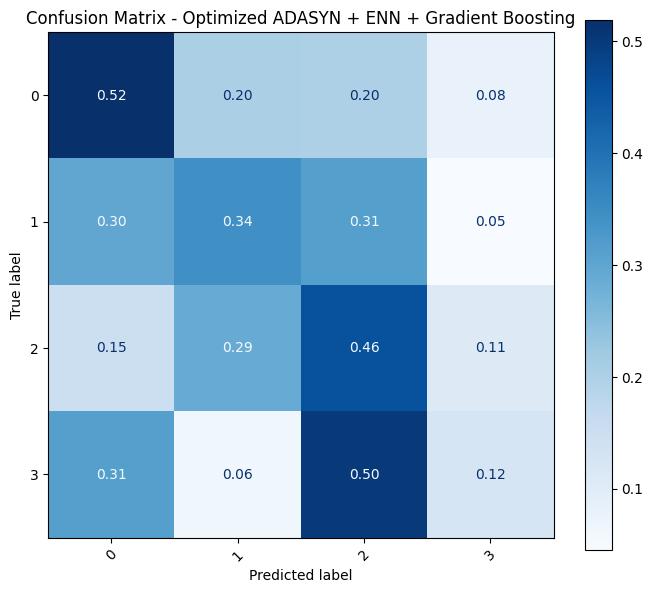

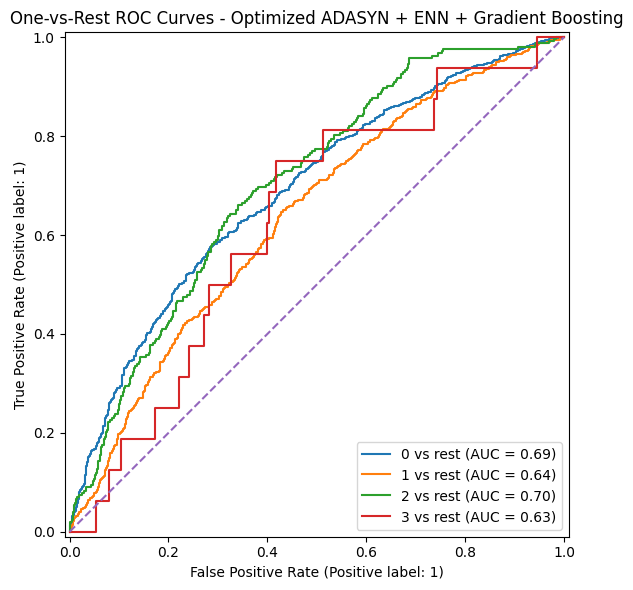

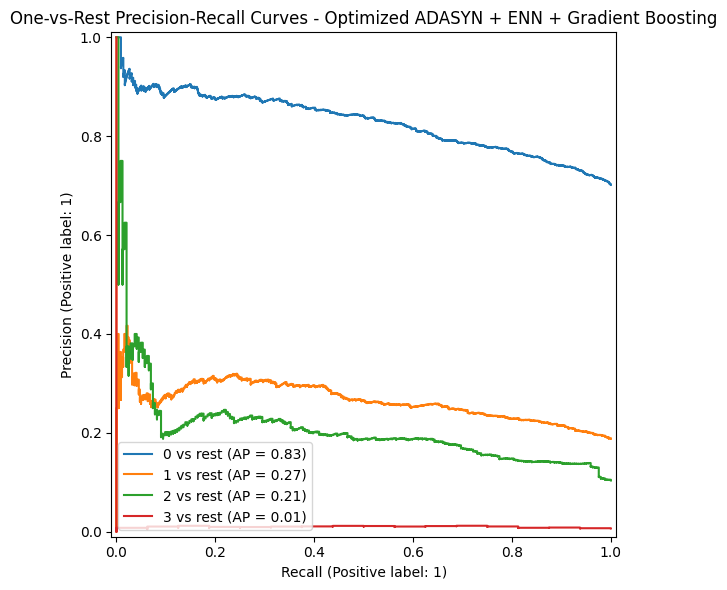


Classification report - Optimized ADASYN + ENN + Gradient Boosting


,precision,recall,f1-score,support
0,0.832039,0.519394,0.639552,1650.000000
1,0.272401,0.343891,0.304000,442.000000
2,0.190801,0.459016,0.269555,244.000000
3,0.011299,0.125000,0.020725,16.000000
accuracy,0.477466,0.477466,0.477466,0.477466
macro avg,0.326635,0.361825,0.308458,2352.000000
weighted avg,0.654763,0.477466,0.533900,2352.000000


In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Grafia britannica con la 'u'
from imblearn.pipeline import Pipeline as ImbPipeline              # Per evitare Data Leakage

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi per Pipeline)
# =========================================================================
param_dist_hybrid_gb = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri del Gradient Boosting Classifier (prefisso 'gb__')
    'gb__n_estimators': [50, 100, 200, 300],
    'gb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'gb__max_depth': [3, 4, 5, 7],
    'gb__min_samples_split': [2, 5, 10],
    'gb__min_samples_leaf': [1, 2, 4],
    'gb__max_features': ['sqrt', 'log2', None]
}

# 2. Inizializziamo i componenti della pipeline
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')
gb_base = GradientBoostingClassifier(random_state=42)

# 3. Costruiamo la Pipeline Ibrida Sequenziale
pipeline_gb_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), # Fase 1: Generazione campioni sintetici sulle minoritarie
    ('enn', enn_sampler),       # Fase 2: Pulizia del rumore e delle sovrapposizioni geometriche
    ('gb', gb_base)             # Fase 3: Classificazione con Gradient Boosting
])

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting ADASYN + ENN + Gradient Boosting Hyperparameter Tuning...")

random_search_hybrid_gb = RandomizedSearchCV(
    estimator=pipeline_gb_hybrid,
    param_distributions=param_dist_hybrid_gb,
    n_iter=30,                     # 30 combinazioni stocastiche nella griglia
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla macro-media delle recall
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Il fit applicherà la catena di ricampionamento fold per fold in totale sicurezza
random_search_hybrid_gb.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_gb = random_search_hybrid_gb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_gb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_gb.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Hybrid GB Model on Test Set...")

# La pipeline applicherà in automatico solo il predict del modello sul test set reale sbilanciato
results, report_df = evaluate_classifier(
    model=best_pipeline_gb,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="Optimized ADASYN + ENN + Gradient Boosting",
    normalize_cm="true" 
)

## 3 classes, balanced (Adasyn + ENN)

=== STEP 1: CLASS AGGREGATION ===
Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

=== STEP 2: STRATIFIED DATA SPLIT ===
Train Set Shape: (6271, 32) | Test Set Shape: (1568, 32)

=== STEP 3: HYPERPARAMETER TUNING (ADASYN + ENN + GB) ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'gb__n_estimators': 200, 'gb__min_samples_split': 5, 'gb__min_samples_leaf': 4, 'gb__max_features': None, 'gb__max_depth': 3, 'gb__learning_rate': 0.05, 'enn__n_neighbors': 7, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 7}
Best Balanced Accuracy Score (CV): 0.4917

=== STEP 4: FINAL EVALUATION ON TEST SET ===


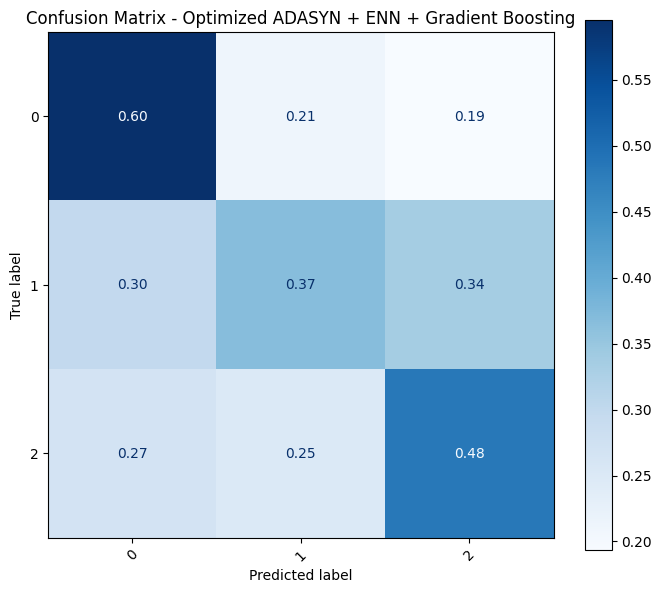

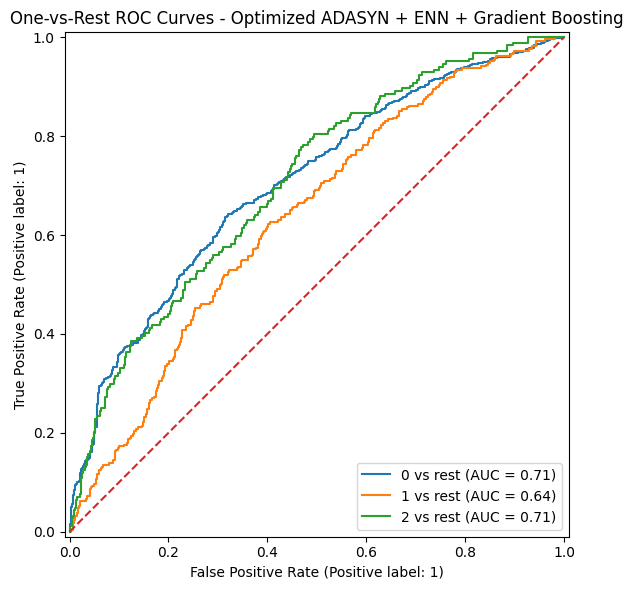

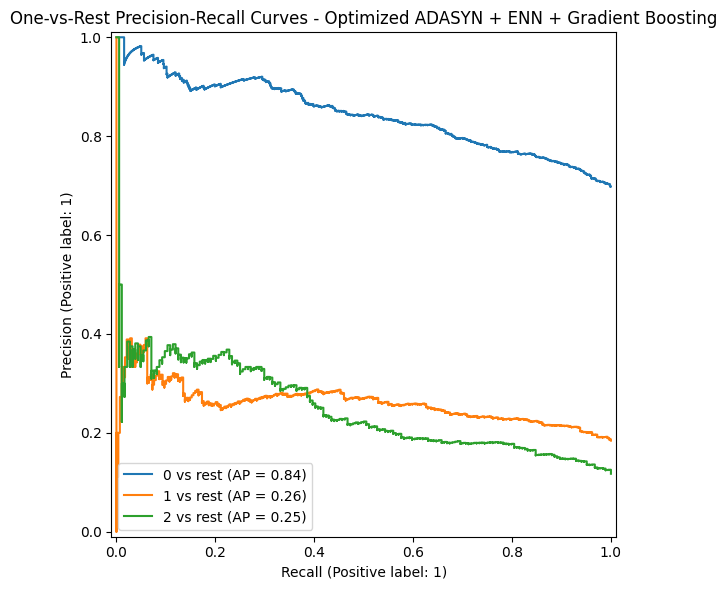


Classification report - Optimized ADASYN + ENN + Gradient Boosting


,precision,recall,f1-score,support
0,0.828463,0.595434,0.692880,1095.000000
1,0.276762,0.366782,0.315476,289.000000
2,0.223618,0.483696,0.305842,184.000000
accuracy,0.540179,0.540179,0.540179,0.540179
macro avg,0.442948,0.481970,0.438066,1568.000000
weighted avg,0.655801,0.540179,0.577902,1568.000000


In [11]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Grafia britannica con la 'u'
from imblearn.pipeline import Pipeline as ImbPipeline              # Per evitare Data Leakage

# =========================================================================
# 1. ACCORPAMENTO DELLE CLASSI (Da 4 macro-categorie a 3)
# =========================================================================
print("=== STEP 1: CLASS AGGREGATION ===")
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso controllato: {0: 5476, 1: 1444, 2: 919}

# =========================================================================
# 2. STRATIFIED TRAIN/TEST SPLIT (A 3 CLASSI)
# =========================================================================
print("\n=== STEP 2: STRATIFIED DATA SPLIT ===")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

print(f"Train Set Shape: {X_train.shape} | Test Set Shape: {X_test.shape}")

# =========================================================================
# 3. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi per Pipeline)
# =========================================================================
param_dist_hybrid_gb = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri del Gradient Boosting Classifier (prefisso 'gb__')
    'gb__n_estimators': [50, 100, 200, 300],
    'gb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'gb__max_depth': [3, 4, 5, 7],
    'gb__min_samples_split': [2, 5, 10],
    'gb__min_samples_leaf': [1, 2, 4],
    'gb__max_features': ['sqrt', 'log2', None]
}

# =========================================================================
# 4. COSTRUZIONE DELLA PIPELINE IBRIDA PROTETTA
# =========================================================================
# ADASYN bilancia geometricamente i volumi delle classi minoritarie
adasyn_sampler = ADASYN(random_state=42)

# ENN ripulisce i confini confusi su tutte le classi dopo l'intervento di ADASYN
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Modello base Gradient Boosting
gb_base = GradientBoostingClassifier(random_state=42)

# Incapsuliamo tutto nella pipeline sequenziale per bloccare il Data Leakage nei fold
pipeline_gb_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), 
    ('enn', enn_sampler),       
    ('gb', gb_base)             
])

# =========================================================================
# 5. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 3: HYPERPARAMETER TUNING (ADASYN + ENN + GB) ===")

random_search_hybrid_gb = RandomizedSearchCV(
    estimator=pipeline_gb_hybrid,
    param_distributions=param_dist_hybrid_gb,
    n_iter=30,                     # Numero di combinazioni casuali da esplorare
    cv=5,                          # 5-Fold Cross-Validation stratificata sulle 3 nuove classi
    scoring='balanced_accuracy',   # Target di ottimizzazione mirato alle recall
    n_jobs=1,                     # Per evitare problemi di memoria con la pipeline ibrida
    random_state=42,
    verbose=1
)

# Il fit applica l'accoppiata ADASYN+ENN fold per fold in modo sicuro
random_search_hybrid_gb.fit(X_train, y_train)

# Estrazione della pipeline ottimizzata
best_pipeline_gb = random_search_hybrid_gb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_gb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_gb.best_score_:.4f}\n")

# =========================================================================
# 6. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 4: FINAL EVALUATION ON TEST SET ===")

# Invochiamo la tua funzione evaluate_classifier passando la pipeline migliore
results, report_df = evaluate_classifier(
    model=best_pipeline_gb,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi (immacolato)
    y_test=y_test,
    model_name="Optimized ADASYN + ENN + Gradient Boosting",
    normalize_cm="true"
)

# **XGBoost**

## 4 classes, imbalanced

=== STEP 1: DATA PREPARATION (4 CLASSES) ===
Distribuzione originale delle 4 classi (0, 1, 2, 3):
Counter({0: 5476, 1: 1444, 2: 846, 3: 73})

=== STEP 2: HYPERPARAMETER TUNING (XGBOOST) ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.5, 'colsample_bytree': 1.0}
Best Balanced Accuracy Score (CV): 0.3047

=== STEP 3: FINAL EVALUATION ON TEST SET ===


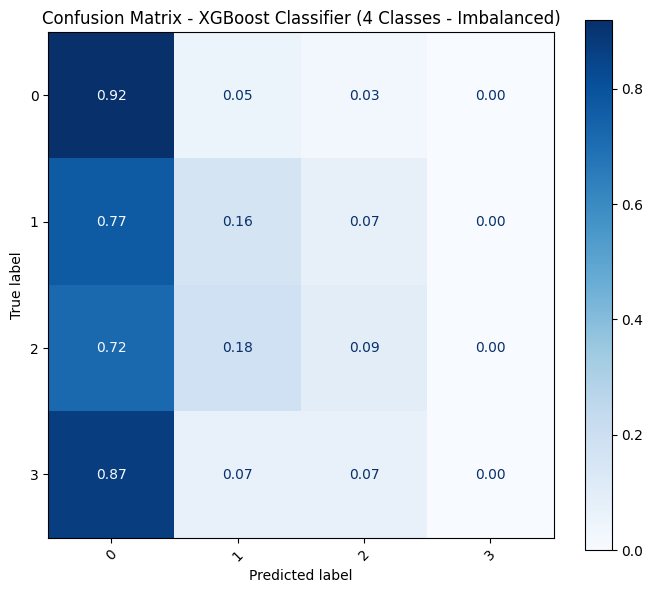

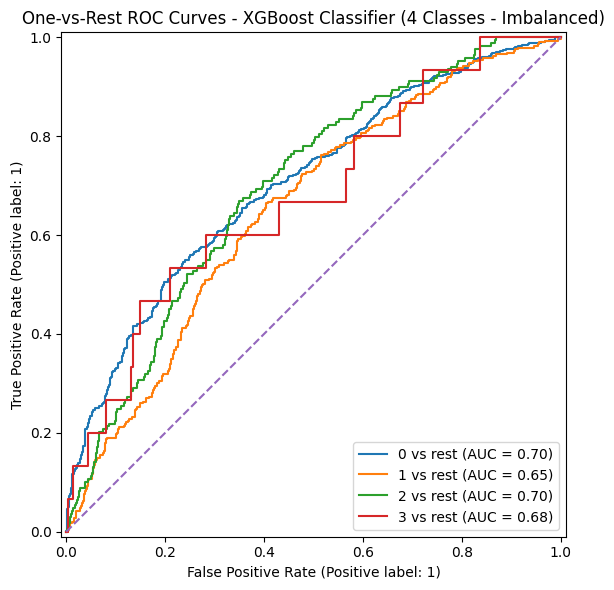

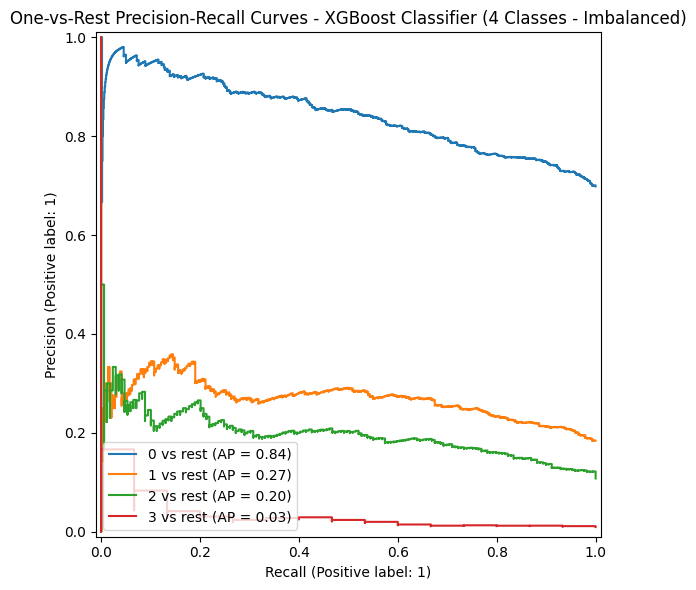


Classification report - XGBoost Classifier (4 Classes - Imbalanced)


,precision,recall,f1-score,support
0,0.738270,0.919635,0.819032,1095.00000
1,0.333333,0.159170,0.215457,289.00000
2,0.242424,0.094675,0.136170,169.00000
3,0.000000,0.000000,0.000000,15.00000
accuracy,0.681760,0.681760,0.681760,0.68176
macro avg,0.328507,0.293370,0.292665,1568.00000
weighted avg,0.603130,0.681760,0.626352,1568.00000


In [12]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from collections import Counter

# =========================================================================
# 1. PREPARAZIONE DATI 4 CLASSI
# =========================================================================
print("=== STEP 1: DATA PREPARATION (4 CLASSES) ===")

# IMPORTANTE: Assicuriamoci che i tag vadano da 0 a 3. 
# Sottraiamo 1 per allinearli a XGBoost.
if df['sii'].min() == 1:
    y_clean_4classes = df['sii'] - 1
else:
    y_clean_4classes = df['sii']

print("Distribuzione originale delle 4 classi (0, 1, 2, 3):")
print(Counter(y_clean_4classes))

# Train/Test Split stratificato sulle 4 classi originarie
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_4classes, test_size=0.2, random_state=42, stratify=y_clean_4classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_xgb = {
    # Numero di round di boosting (alberi sequenziali)
    'n_estimators': [50, 100, 200, 300], # contrassta l'overfitting
    
    # Learning rate (eta): contrasta l'overfitting scalando i pesi dei nuovi alberi
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # contrasta l'overfitting
    
    # Massima profondità dell'albero (valori alti aumentano la complessità)
    # Rimuoviamo il -1 per garantire la stabilità con la crescita depth-wise di XGBoost
    'max_depth': [3, 4, 5, 7, 9], # contrasta l'overfitting
    
    # Peso minimo richiesto in un nodo figlio (regolarizzazione contro overfitting)
    'min_child_weight': [1, 3, 5, 7], # contrasta l'overfitting
    
    # Subsample: percentuale di campioni da campionare casualmente per ogni albero
    'subsample': [0.6, 0.8, 1.0], # evita che ogni albero veda tutti i dati
    
    # Colsample_bytree: percentuale di feature da considerare per ogni albero
    'colsample_bytree': [0.6, 0.8, 1.0], # evita che ogni albero veda tutte le feature

    # Gamma: riduce la complessità dell'albero richiedendo una riduzione minima di loss per fare uno split
    'gamma': [0, 0.1, 0.2, 0.5, 1.0, 5.0],
    
    # Parametri di regolarizzazione matematica nativi di XGBoost
    'reg_alpha': [0, 0.1, 1.0],   # Regolarizzazione L1 (Lasso)
    'reg_lambda': [1.0, 5.0, 10.0] # Regolarizzazione L2 (Ridge)
}

# Modello base XGBoost configurato per classificazione multiclasse
# Spostiamo n_jobs qui dentro per evitare bug di serializzazione con joblib
xgb_base = XGBClassifier(
    objective='multi:softprob', 
    eval_metric='mlogloss',
    n_jobs=-1, 
    random_state=42
)

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (XGBOOST) ===")

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=40,                     # Numero di combinazioni stocastiche da testare
    cv=5,                          # 5-Fold Cross-Validation stratificata sulle 4 classi
    scoring='balanced_accuracy',   # Ottimizziamo per mitigare l'effetto dello sbilanciamento nei fold
    n_jobs=1,                      # Lasciamo 1 qui, il parallelismo è gestito internamente da XGBoost
    random_state=42,
    verbose=1
)

# Avvio del fitting sui dati sbilanciati a 4 classi
random_search_xgb.fit(X_train, y_train)

# Estrazione del modello migliore
best_xgb = random_search_xgb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_xgb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_xgb.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Essendo l'XGBClassifier un estimatore pienamente compatibile con Scikit-Learn,
# lo passiamo direttamente alla tua funzione originale per calcolare metriche e matrici
results, report_df = evaluate_classifier(
    model=best_xgb,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="XGBoost Classifier (4 Classes - Imbalanced)",
    normalize_cm="true"
)

## 4 classes, balanced (Adasyn + ENN)

=== STEP 1: DATA PREPARATION (4 CLASSES) ===
Distribuzione originale delle 4 classi:
Counter({0: 5476, 1: 1444, 2: 846, 3: 73})

=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + XGBOOST) ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'xgb__subsample': 0.8, 'xgb__reg_lambda': 5.0, 'xgb__reg_alpha': 1.0, 'xgb__n_estimators': 100, 'xgb__min_child_weight': 7, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 1.0, 'enn__n_neighbors': 7, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 5}
Best Balanced Accuracy Score (CV): 0.3755

=== STEP 3: FINAL EVALUATION ON TEST SET ===


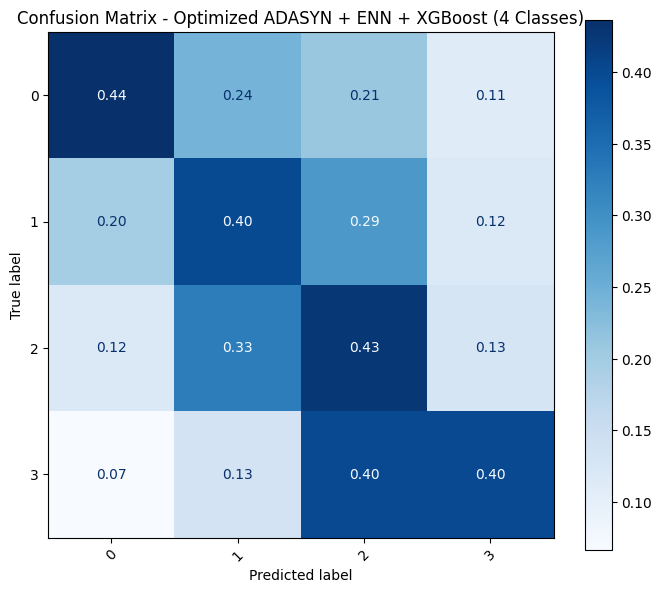

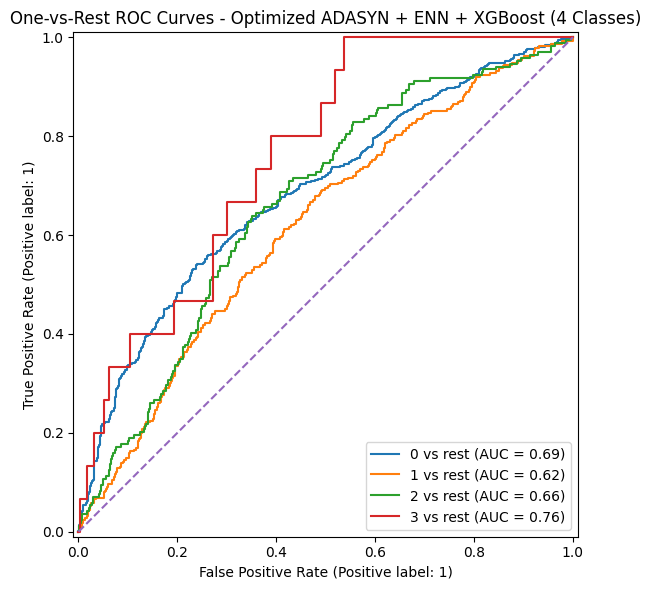

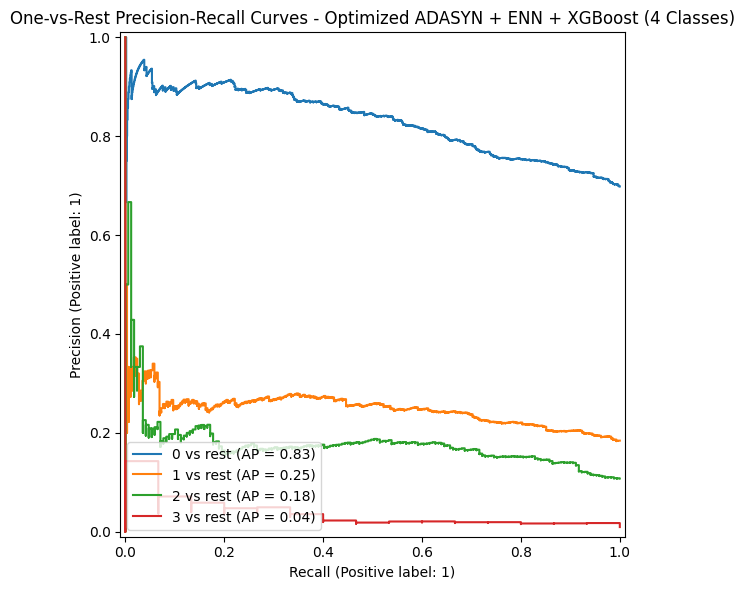


Classification report - Optimized ADASYN + ENN + XGBoost (4 Classes)


,precision,recall,f1-score,support
0,0.859712,0.436530,0.579043,1095.000000
1,0.262557,0.397924,0.316369,289.000000
2,0.184143,0.426036,0.257143,169.000000
3,0.032787,0.400000,0.060606,15.000000
accuracy,0.427934,0.427934,0.427934,0.427934
macro avg,0.334800,0.415122,0.303290,1568.000000
weighted avg,0.668926,0.427934,0.490975,1568.000000


In [17]:
import numpy as np
import pandas as pd
from collections import Counter
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Grafia britannica con la 'u'
from imblearn.pipeline import Pipeline as ImbPipeline              # Per evitare Data Leakage

# =========================================================================
# 1. DATA PREPARATION (4 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: DATA PREPARATION (4 CLASSES) ===")

# Portiamo le classi a [0, 1, 2, 3]
if df['sii'].min() == 1:
    y_clean_4classes = df['sii'] - 1
else:
    y_clean_4classes = df['sii']

print("Distribuzione originale delle 4 classi:")
print(Counter(y_clean_4classes))

# Train/Test Split stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_4classes, test_size=0.2, random_state=42, stratify=y_clean_4classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefisso 'xgb__')
# =========================================================================
param_dist_hybrid_xgb = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri di XGBoost (notare la griglia ottimizzata senza num_leaves o max_depth=-1)
    'xgb__n_estimators': [50, 100, 200, 300],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__max_depth': [3, 4, 5, 7, 9], 
    'xgb__min_child_weight': [1, 3, 5, 7],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.2, 0.5, 1.0, 5.0],
    'xgb__reg_alpha': [0, 0.1, 1.0],   
    'xgb__reg_lambda': [1.0, 5.0, 10.0] 
}

# =========================================================================
# 3. COSTRUZIONE DELLA PIPELINE IBRIDA PROTETTA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Modello base XGBoost. Lasciamo n_jobs=-1 qui dentro, così il multi-threading 
# è gestito a basso livello in C++ evitando errori di serializzazione con joblib.
xgb_base = XGBClassifier(
    objective='multi:softprob', 
    eval_metric='mlogloss',
    n_jobs=-1, 
    random_state=42
)

pipeline_xgb_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), # Fase 1: Oversampling intelligente
    ('enn', enn_sampler),       # Fase 2: Pulizia dei confini di tutte le classi
    ('xgb', xgb_base)           # Fase 3: Classificazione
])

# =========================================================================
# 4. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + XGBOOST) ===")

random_search_hybrid_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb_hybrid,
    param_distributions=param_dist_hybrid_xgb,
    n_iter=30,                     # Numero di combinazioni casuali da testare
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Target di ottimizzazione mirato alla macro-media delle recall
    n_jobs=1,                      # Lasciamo 1 qui, il parallelismo è delegato internamente a XGBoost
    random_state=42,
    verbose=1
)

# Il fit applica il ricampionamento e la pulizia fold per fold in totale sicurezza
random_search_hybrid_xgb.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_xgb = random_search_hybrid_xgb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_xgb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_xgb.best_score_:.4f}\n")

# =========================================================================
# 5. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Passiamo la pipeline vincente direttamente alla tua funzione originale
results, report_df = evaluate_classifier(
    model=best_pipeline_xgb,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi (immacolato)
    y_test=y_test,
    model_name="Optimized ADASYN + ENN + XGBoost (4 Classes)",
    normalize_cm="true"
)

## 3 classes, balanced (Adasyn + ENN)

=== STEP 1: CLASS AGGREGATION & ALIGNMENT ===
Nuova distribuzione delle 3 macro-classi (0, 1, 2):
Counter({0: 5476, 1: 1444, 2: 919})

=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + XGBOOST) ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 1.0, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 50, 'xgb__min_child_weight': 1, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.8, 'enn__n_neighbors': 7, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 5}
Best Balanced Accuracy Score (CV): 0.4954

=== STEP 3: FINAL EVALUATION ON TEST SET ===


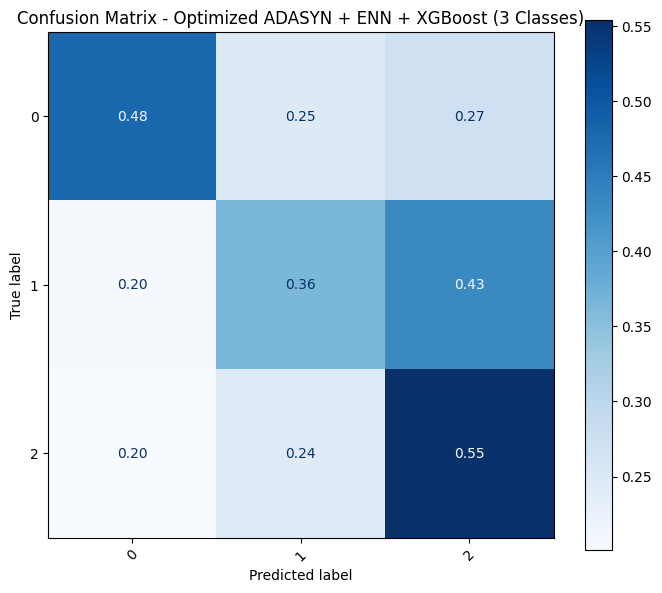

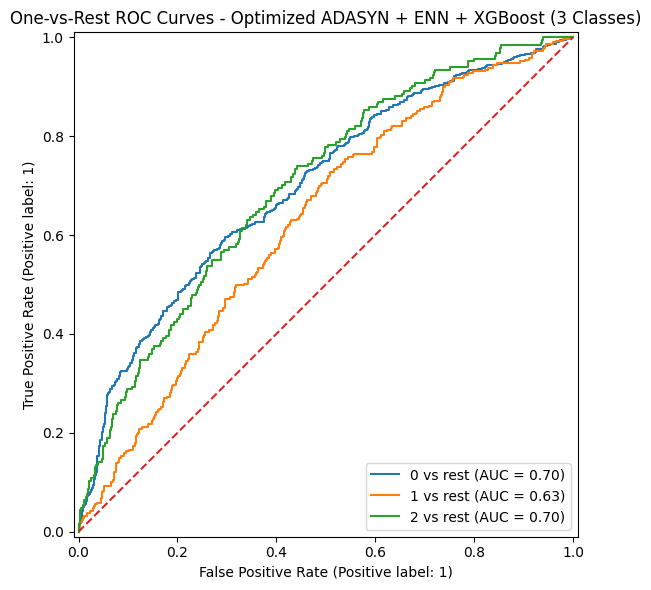

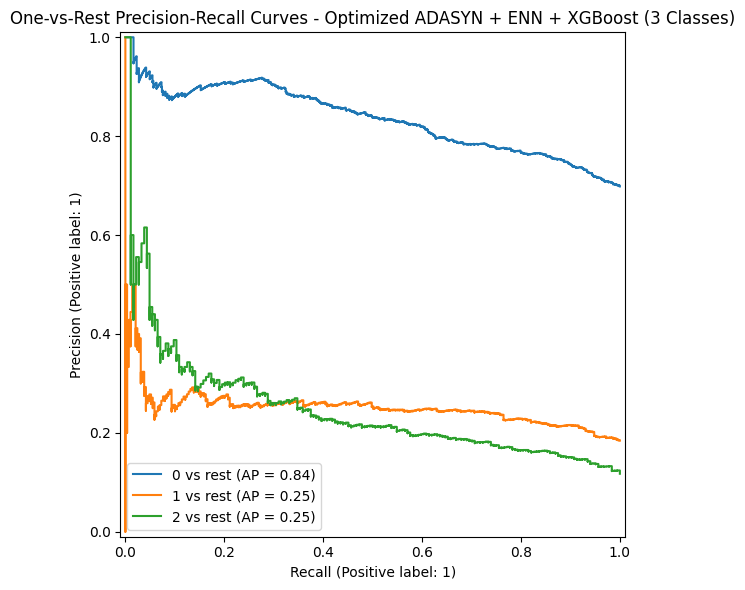


Classification report - Optimized ADASYN + ENN + XGBoost (3 Classes)


,precision,recall,f1-score,support
0,0.845411,0.479452,0.611888,1095.000000
1,0.250597,0.363322,0.296610,289.000000
2,0.193182,0.554348,0.286517,184.000000
accuracy,0.466837,0.466837,0.466837,0.466837
macro avg,0.429730,0.465707,0.398338,1568.000000
weighted avg,0.659243,0.466837,0.515598,1568.000000


In [16]:
import numpy as np
import pandas as pd
from collections import Counter
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Grafia britannica con la 'u'
from imblearn.pipeline import Pipeline as ImbPipeline              # Per evitare Data Leakage

# =========================================================================
# 1. ACCORPAMENTO CLINICO E PREPARAZIONE DATI (3 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: CLASS AGGREGATION & ALIGNMENT ===")

# Uniamo la classe 3 e 4 sotto il tag 2
y_clean_3classes = df['sii'].replace({3: 2})

# IMPORTANTE per XGBoost: le etichette devono partire da 0.
# Se dopo l'accorpamento abbiamo [0, 1, 2] siamo già a posto. 
# Se avevamo [1, 2, 3], sottraiamo 1 per portarle a [0, 1, 2].
if y_clean_3classes.min() == 1:
    y_clean_3classes = y_clean_3classes - 1

print("Nuova distribuzione delle 3 macro-classi (0, 1, 2):")
print(Counter(y_clean_3classes))

# Train/Test Split stratificato sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefisso 'xgb__')
# =========================================================================
param_dist_hybrid_xgb = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri di XGBoost ottimizzati per la stabilità sintattica
    'xgb__n_estimators': [50, 100, 200, 300],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__max_depth': [3, 4, 5, 7, 9], 
    'xgb__min_child_weight': [1, 3, 5, 7],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.2, 0.5, 1.0, 5.0],
    'xgb__reg_alpha': [0, 0.1, 1.0],   # Regolarizzazione L1 (Sparsity delle feature)
    'xgb__reg_lambda': [1.0, 5.0, 10.0] # Regolarizzazione L2 (Stabilità dei pesi)
}

# =========================================================================
# 3. COSTRUZIONE DELLA PIPELINE IBRIDA PROTETTA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)

# Impostiamo 'all' perché l'ENN agirà dopo l'ADASYN, ripulendo i confini confusi
# su tutte le classi, comprese le minoritarie che ora hanno massa critica
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Modello base XGBoost configurato per 3 classi (multi:softprob)
xgb_base = XGBClassifier(
    objective='multi:softprob', 
    eval_metric='mlogloss',
    n_jobs=-1, # Il parallelismo è gestito nativamente in C++ da XGBoost senza toccare joblib
    random_state=42
)

# La sequenza geometrica scientificamente approvata
pipeline_xgb_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), # Fase 1: Espansione adattiva delle classi 1 e 2
    ('enn', enn_sampler),       # Fase 2: Pulizia chirurgica delle sovrapposizioni
    ('xgb', xgb_base)           # Fase 3: Classificazione tramite Gradient Boosting
])

# =========================================================================
# 4. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + XGBOOST) ===")

random_search_hybrid_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb_hybrid,
    param_distributions=param_dist_hybrid_xgb,
    n_iter=30,                     # Numero di combinazioni casuali da testare
    cv=5,                          # 5-Fold Cross-Validation stratificata sulle 3 nuove classi
    scoring='balanced_accuracy',   # Obiettivo coerente con la gestione dello sbilanciamento
    n_jobs=1,                      # Manteniamo 1 per evitare conflitti con la serializzazione di imblearn
    random_state=42,
    verbose=1
)

# Il fit applica l'accoppiata ADASYN + ENN fold per fold in totale sicurezza
random_search_hybrid_xgb.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_xgb = random_search_hybrid_xgb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_xgb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_xgb.best_score_:.4f}\n")

# =========================================================================
# 5. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Passiamo la pipeline vincente direttamente alla tua funzione originale
results, report_df = evaluate_classifier(
    model=best_pipeline_xgb,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi (immacolato)
    y_test=y_test,
    model_name="Optimized ADASYN + ENN + XGBoost (3 Classes)",
    normalize_cm="true"
)

# **LightGBM**

## 4 classes, imbalanced

=== STEP 1: DATA PREPARATION (4 CLASSES) ===
Distribuzione originale delle 4 classi:
Counter({0: 5476, 1: 1444, 2: 846, 3: 73})

=== STEP 2: HYPERPARAMETER TUNING (LIGHTGBM) ===
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 5.0, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 30, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best Balanced Accuracy Score (CV): 0.3061

=== STEP 3: FINAL EVALUATION ON TEST SET ===


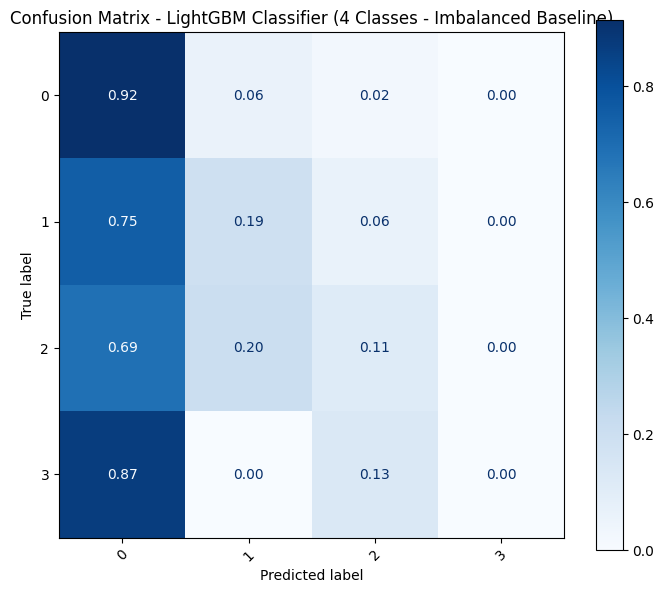

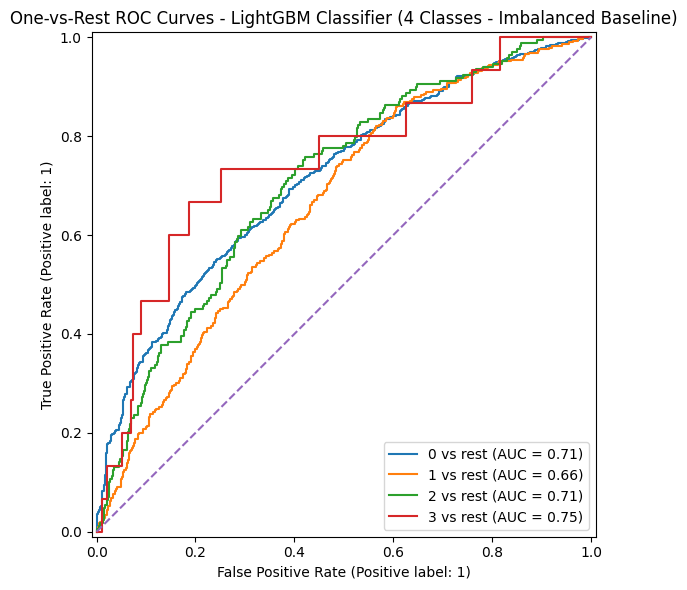

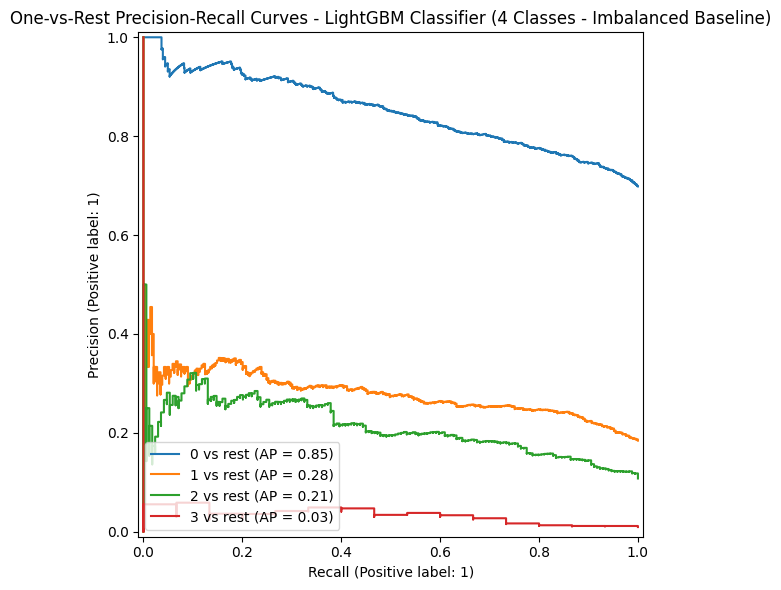


Classification report - LightGBM Classifier (4 Classes - Imbalanced Baseline)


,precision,recall,f1-score,support
0,0.743323,0.915068,0.820303,1095.000000
1,0.350649,0.186851,0.243792,289.000000
2,0.287879,0.112426,0.161702,169.000000
3,0.000000,0.000000,0.000000,15.000000
accuracy,0.685587,0.685587,0.685587,0.685587
macro avg,0.345463,0.303586,0.306449,1568.000000
weighted avg,0.614750,0.685587,0.635214,1568.000000


In [19]:
import numpy as np
import pandas as pd
from collections import Counter
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# =========================================================================
# 1. PREPARAZIONE DATI (4 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: DATA PREPARATION (4 CLASSES) ===")

# Portiamo le classi a [0, 1, 2, 3]
if df['sii'].min() == 1:
    y_clean_4classes = df['sii'] - 1
else:
    y_clean_4classes = df['sii']

print("Distribuzione originale delle 4 classi:")
print(Counter(y_clean_4classes))

X = df.drop(columns=['sii']) # Assumendo che 'sii' sia la colonna target

# Train/Test Split stratificato sulle 4 classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_4classes, test_size=0.2, random_state=42, stratify=y_clean_4classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_lgb = {
    # Numero di alberi (round di boosting)
    'n_estimators': [50, 100, 200, 300],
    
    # Tasso di apprendimento (passo di aggiornamento del gradiente)
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    
    # PARAMETRO CHIAVE DI LIGHTGBM: Massimo numero di foglie in un albero
    'num_leaves': [15, 31, 63, 127],
    
    # Massima profondità (lasciamo -1 per affidarci a num_leaves, o range controllati)
    'max_depth': [-1, 3, 5, 7, 9],
    
    # Numero minimo di dati (campioni) necessari in una foglia per permettere lo split
    'min_child_samples': [10, 20, 30, 50],
    
    # Subsample (bagging_fraction): percentuale di dati usata per ogni albero
    'subsample': [0.6, 0.8, 1.0],
    
    # Colsample_bytree (feature_fraction): percentuale di feature considerata ad ogni albero
    'colsample_bytree': [0.6, 0.8, 1.0],
    
    # Regolarizzazione matematica (L1 e L2)
    'reg_alpha': [0.0, 0.1, 1.0, 5.0],  # Regolarizzazione L1 (Lasso)
    'reg_lambda': [0.0, 1.0, 5.0, 10.0] # Regolarizzazione L2 (Ridge)
}

# Modello base LightGBM configurato per multiclasse
# Impostiamo n_jobs=-1 qui, delegando il parallelismo alla libreria OpenMP interna di LightGBM
lgb_base = LGBMClassifier(
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    verbose=-1 # Disattiva i log ripetitivi di LightGBM nei fold
)

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (LIGHTGBM) ===")

random_search_lgb = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist_lgb,
    n_iter=40,                     # Numero di combinazioni casuali da testare
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Metrica obiettivo stabile per dati sbilanciati
    n_jobs=1,                      # Manteniamo 1, il parallelismo è già attivo dentro LightGBM
    random_state=42,
    verbose=1
)

# Il fit addestrerà i modelli sulla combinazione foglia per foglia
random_search_lgb.fit(X_train, y_train)

# Estrazione del modello migliore
best_lgb = random_search_lgb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_lgb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_lgb.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Essendo LGBMClassifier compatibile al 100% con gli standard Scikit-Learn,
# lo passiamo direttamente alla tua funzione originale per metriche e matrici
results, report_df = evaluate_classifier(
    model=best_lgb,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="LightGBM Classifier (4 Classes - Imbalanced Baseline)",
    normalize_cm="true"
)

## 4 classes, balanced (Adasyn + ENN)

=== STEP 1: DATA PREPARATION (4 CLASSES) ===
Distribuzione originale delle 4 classi:
Counter({0: 5476, 1: 1444, 2: 846, 3: 73})

=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + LIGHTGBM) ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'lgb__subsample': 0.8, 'lgb__reg_lambda': 10.0, 'lgb__reg_alpha': 0.1, 'lgb__num_leaves': 127, 'lgb__n_estimators': 100, 'lgb__min_child_samples': 50, 'lgb__max_depth': 3, 'lgb__learning_rate': 0.01, 'lgb__colsample_bytree': 0.8, 'enn__n_neighbors': 7, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 7}
Best Balanced Accuracy Score (CV): 0.3859

=== STEP 3: FINAL EVALUATION ON TEST SET ===


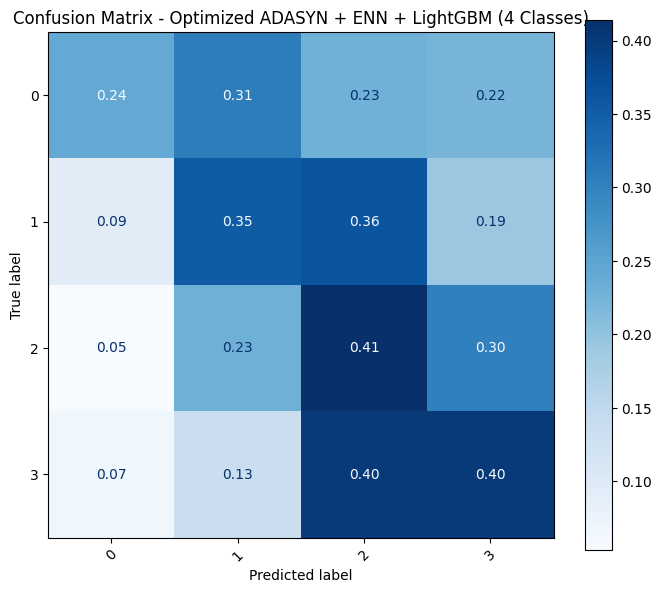

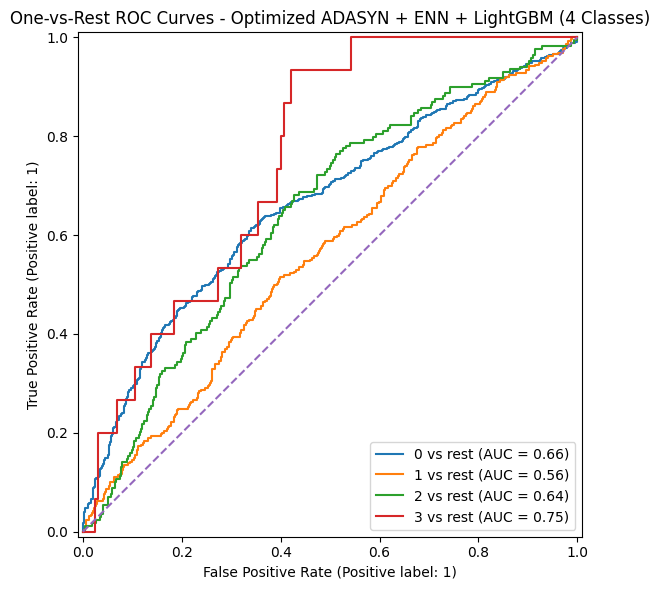

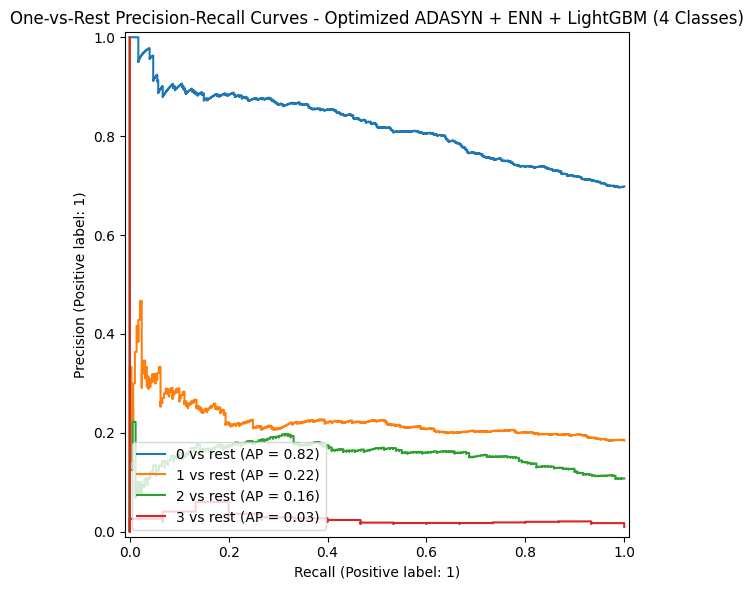


Classification report - Optimized ADASYN + ENN + LightGBM (4 Classes)


,precision,recall,f1-score,support
0,0.877076,0.241096,0.378223,1095.000000
1,0.212944,0.352941,0.265625,289.000000
2,0.162037,0.414201,0.232945,169.000000
3,0.016854,0.400000,0.032345,15.000000
accuracy,0.281888,0.281888,0.281888,0.281888
macro avg,0.317228,0.352060,0.227285,1568.000000
weighted avg,0.669373,0.281888,0.338503,1568.000000


In [20]:
import numpy as np
import pandas as pd
from collections import Counter
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Grafia britannica con la 'u'
from imblearn.pipeline import Pipeline as ImbPipeline              # Per evitare Data Leakage

# =========================================================================
# 1. PREPARAZIONE DATI (4 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: DATA PREPARATION (4 CLASSES) ===")

# Se nel tuo df originale le classi erano [1, 2, 3, 4], le portiamo a [0, 1, 2, 3]
if df['sii'].min() == 1:
    y_clean_4classes = df['sii'] - 1
else:
    y_clean_4classes = df['sii']

print("Distribuzione originale delle 4 classi:")
print(Counter(y_clean_4classes))

X = df.drop(columns=['sii']) 

# Train/Test Split stratificato sulle 4 classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_4classes, test_size=0.2, random_state=42, stratify=y_clean_4classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefisso 'lgb__')
# =========================================================================
param_dist_hybrid_lgb = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri di LightGBM (notare il prefisso 'lgb__')
    'lgb__n_estimators': [50, 100, 200, 300],
    'lgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'lgb__num_leaves': [15, 31, 63, 127],
    'lgb__max_depth': [-1, 3, 5, 7, 9],
    'lgb__min_child_samples': [10, 20, 30, 50],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0],
    'lgb__reg_alpha': [0.0, 0.1, 1.0, 5.0],   # Regolarizzazione L1 (Lasso)
    'lgb__reg_lambda': [0.0, 1.0, 5.0, 10.0]  # Regolarizzazione L2 (Ridge)
}

# =========================================================================
# 3. COSTRUZIONE DELLA PIPELINE IBRIDA PROTETTA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Modello base LightGBM. Sfruttiamo il parallelismo integrato (n_jobs=-1) 
# gestito a basso livello tramite OpenMP, evitando conflitti con joblib.
lgb_base = LGBMClassifier(
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Pipeline sequenziale: previene matematicamente il Data Leakage nei fold di CV
pipeline_lgb_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), # Fase 1: Sovracampionamento adattivo
    ('enn', enn_sampler),       # Fase 2: Pulizia delle zone di sovrapposizione geometrica
    ('lgb', lgb_base)           # Fase 3: Classificazione strutturata leaf-wise
])

# =========================================================================
# 4. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + LIGHTGBM) ===")

random_search_hybrid_lgb = RandomizedSearchCV(
    estimator=pipeline_lgb_hybrid,
    param_distributions=param_dist_hybrid_lgb,
    n_iter=30,                     # Numero di combinazioni casuali da esplorare
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla media delle recall specifiche
    n_jobs=1,                      # Manteniamo 1 a livello macro, il parallelismo è delegato a LightGBM
    random_state=42,
    verbose=1
)

# Il fit eseguirà la catena ADASYN -> ENN -> LightGBM in modo sicuro su ogni fold
random_search_hybrid_lgb.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_lgb = random_search_hybrid_lgb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_lgb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_lgb.best_score_:.4f}\n")

# =========================================================================
# 5. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Invochiamo la tua funzione evaluate_classifier passando la pipeline migliore
results, report_df = evaluate_classifier(
    model=best_pipeline_lgb,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi (immacolato)
    y_test=y_test,
    model_name="Optimized ADASYN + ENN + LightGBM (4 Classes)",
    normalize_cm="true"
)

## 3 classes, balanced (Adasyn + ENN)

=== STEP 1: CLASS AGGREGATION & ALIGNMENT ===
Nuova distribuzione delle 3 macro-classi (0, 1, 2):
Counter({0: 5476, 1: 1444, 2: 919})

=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + LIGHTGBM - 3 CLASSES) ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'lgb__subsample': 0.8, 'lgb__reg_lambda': 10.0, 'lgb__reg_alpha': 1.0, 'lgb__num_leaves': 31, 'lgb__n_estimators': 200, 'lgb__min_child_samples': 10, 'lgb__max_depth': 7, 'lgb__learning_rate': 0.05, 'lgb__colsample_bytree': 1.0, 'enn__n_neighbors': 5, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 7}
Best Balanced Accuracy Score (CV): 0.4817

=== STEP 3: FINAL EVALUATION ON TEST SET ===


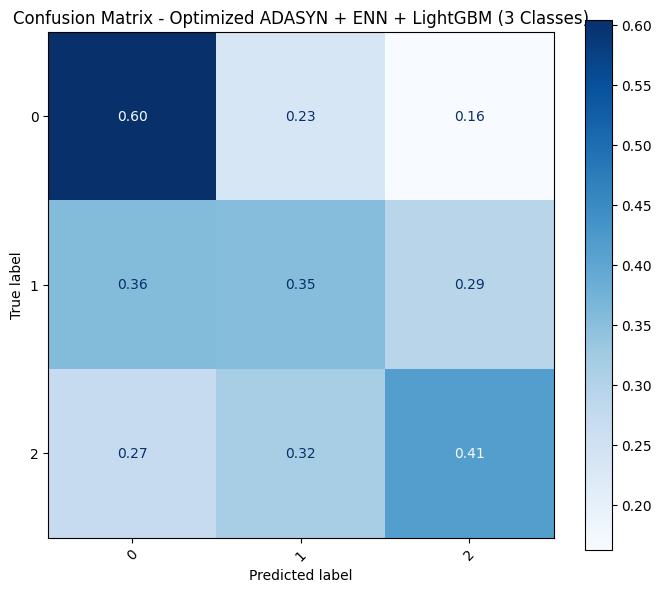

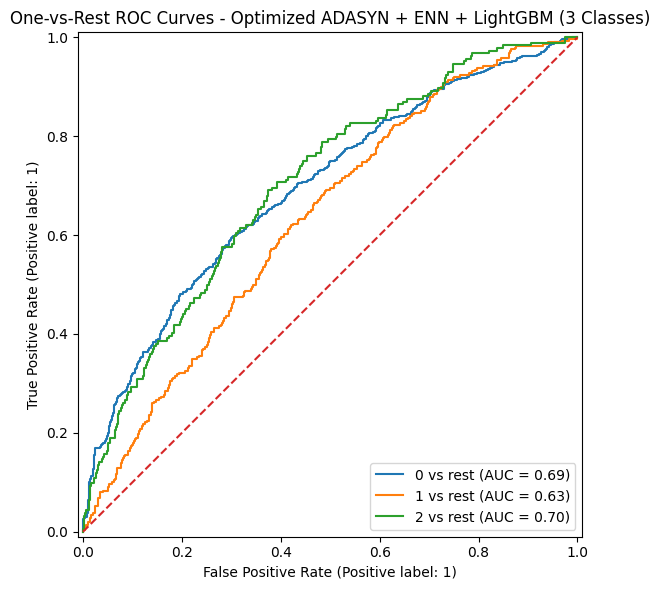

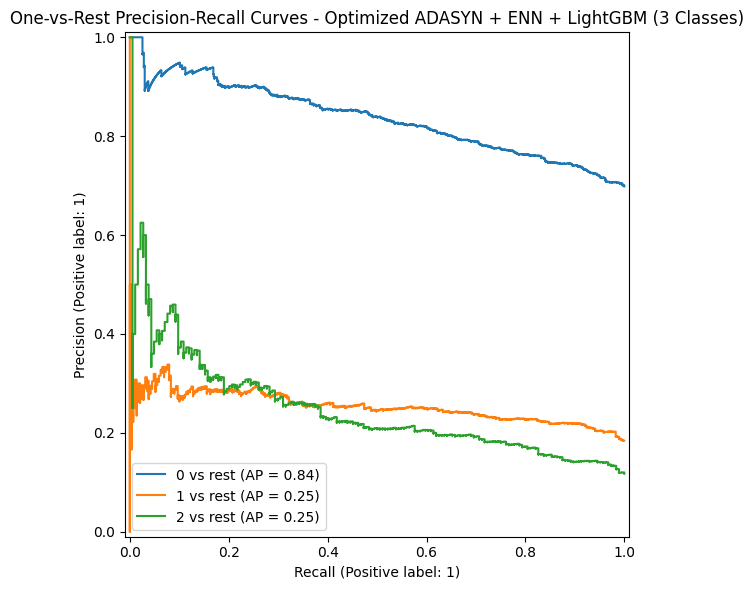


Classification report - Optimized ADASYN + ENN + LightGBM (3 Classes)


,precision,recall,f1-score,support
0,0.812270,0.604566,0.693194,1095.000000
1,0.245783,0.352941,0.289773,289.000000
2,0.224852,0.413043,0.291188,184.000000
accuracy,0.535714,0.535714,0.535714,0.535714
macro avg,0.427635,0.456850,0.424718,1568.000000
weighted avg,0.638928,0.535714,0.571665,1568.000000


In [31]:
import numpy as np
import pandas as pd
from collections import Counter
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Grafia britannica con la 'u'
from imblearn.pipeline import Pipeline as ImbPipeline              # Per evitare Data Leakage

# =========================================================================
# 1. ACCORPAMENTO CLINICO E PREPARAZIONE DATI (3 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: CLASS AGGREGATION & ALIGNMENT ===")

# Uniamo la classe 3 e 4 sotto il tag 2
y_clean_3classes = df['sii'].replace({3: 2})

# IMPORTANTE per LightGBM: le etichette devono partire da 0.
# Se dopo l'accorpamento abbiamo [0, 1, 2] siamo già a posto. 
# Se avevamo [1, 2, 3], sottraiamo 1 per portarle a [0, 1, 2].
if y_clean_3classes.min() == 1:
    y_clean_3classes = y_clean_3classes - 1

print("Nuova distribuzione delle 3 macro-classi (0, 1, 2):")
print(Counter(y_clean_3classes))

X = df.drop(columns=['sii'])
# Train/Test Split stratificato sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefisso 'lgb__')
# =========================================================================
param_dist_hybrid_lgb = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri di LightGBM (prefisso 'lgb__')
    'lgb__n_estimators': [50, 100, 200, 300],
    'lgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'lgb__num_leaves': [15, 31, 63, 127],
    'lgb__max_depth': [-1, 3, 5, 7, 9],
    'lgb__min_child_samples': [10, 20, 30, 50],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0],
    'lgb__reg_alpha': [0.0, 0.1, 1.0, 5.0],   
    'lgb__reg_lambda': [0.0, 1.0, 5.0, 10.0]  
}

# =========================================================================
# 3. COSTRUZIONE DELLA PIPELINE IBRIDA PROTETTA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

lgb_base = LGBMClassifier(
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Pipeline sequenziale antirumore
pipeline_lgb_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), # Fase 1: Generazione adattiva dei campioni sintetici
    ('enn', enn_sampler),       # Fase 2: Pulizia chirurgica delle sovrapposizioni
    ('lgb', lgb_base)           # Fase 3: Classificazione leaf-wise con LightGBM
])

# =========================================================================
# 4. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + LIGHTGBM - 3 CLASSES) ===")

random_search_hybrid_lgb = RandomizedSearchCV(
    estimator=pipeline_lgb_hybrid,
    param_distributions=param_dist_hybrid_lgb,
    n_iter=30,                     
    cv=5,                          
    scoring='balanced_accuracy',   
    n_jobs=1,                      # Parallelismo delegato internamente a LightGBM
    random_state=42,
    verbose=1
)

# Eseguiamo il fit: ricampionamento e pulizia fold per fold in totale sicurezza
random_search_hybrid_lgb.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_lgb = random_search_hybrid_lgb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_lgb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_lgb.best_score_:.4f}\n")

# =========================================================================
# 5. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Passiamo la pipeline ottimizzata direttamente alla tua funzione originale
results, report_df = evaluate_classifier(
    model=best_pipeline_lgb,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi (immacolato)
    y_test=y_test,
    model_name="Optimized ADASYN + ENN + LightGBM (3 Classes)",
    normalize_cm="true"
)

# **CatBoost**

## 4 classes, imbalanced

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# =========================================================================
# 1. PREPARAZIONE DATI (4 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: DATA PREPARATION (4 CLASSES) ===")

# check per allineare le classi a zero, requisito fondamentale per CatBoost
if df['sii'].min() == 1:
    y_clean_4classes = df['sii'] - 1
else:
    y_clean_4classes = df['sii']

print("Distribuzione originale delle 4 classi per CatBoost:")
print(Counter(y_clean_4classes))

X = df.drop(columns=['sii'])
# Train/Test Split stratificato sulle 4 classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_4classes, test_size=0.2, random_state=42, stratify=y_clean_4classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_cat = {
    # Numero di alberi simmetrici da costruire (round di boosting)
    'iterations': [100, 200, 300, 500],
    
    # Tasso di apprendimento
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    
    # Profondità degli alberi simmetrici (CatBoost lavora ottimamente tra 4 e 10)
    'depth': [4, 6, 8, 10],
    
    # Regolarizzazione L2 sui valori delle foglie per frenare l'overfitting
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    
    # Coefficiente di regolarizzazione stocastica sugli split
    'random_strength': [0.0, 1.0, 2.0]
}

# Modello base CatBoost configurato per multiclasse
# thread_count=-1 attiva il parallelismo nativo multi-core
# logging_level='Silent' pulisce l'output della console eliminando migliaia di righe di log
cat_base = CatBoostClassifier(
    loss_function='MultiClass',
    thread_count=-1,
    logging_level='Silent',
    random_state=42
)

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (CATBOOST IMBALANCED) ===")

random_search_cat = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=param_dist_cat,
    n_iter=40,                     # Numero di combinazioni casuali da testare
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Metrica obiettivo stabile contro il bias di maggioranza
    n_jobs=1,                      # Manteniamo 1, il calcolo parallelo è interno a CatBoost
    random_state=42,
    verbose=1
)

# Avviamo il fit direttamente sui dati grezzi sbilanciati
random_search_cat.fit(X_train, y_train)

# Estrazione del modello migliore
best_cat = random_search_cat.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_cat.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_cat.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Passiamo l'oggetto CatBoost ottimizzato alla tua funzione per generare i report
results, report_df = evaluate_classifier(
    model=best_cat,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="CatBoost Classifier (4 Classes - Imbalanced Baseline)",
    normalize_cm="true"
)

## 4 classes, balanced (Adasyn + ENN)

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Per l'undersampling
from imblearn.pipeline import Pipeline as ImbPipeline              # Per bloccare il Data Leakage

# =========================================================================
# 1. PREPARAZIONE DATI (4 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: DATA PREPARATION (4 CLASSES) ===")

# Se nel tuo df originale le classi erano [1, 2, 3, 4], le portiamo a [0, 1, 2, 3]
if df['sii'].min() == 1:
    y_clean_4classes = df['sii'] - 1
else:
    y_clean_4classes = df['sii']

print("Distribuzione originale delle 4 classi:")
print(Counter(y_clean_4classes))

X = df.drop(columns=['sii']) 
# Train/Test Split stratificato sulle 4 classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_4classes, test_size=0.2, random_state=42, stratify=y_clean_4classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefisso 'cat__')
# =========================================================================
param_dist_hybrid_cat = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri di CatBoost (prefisso 'cat__')
    'cat__iterations': [100, 200, 300, 500],      # Numero di alberi simmetrici
    'cat__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'cat__depth': [4, 6, 8, 10],                   # Profondità degli alberi
    'cat__l2_leaf_reg': [1, 3, 5, 7, 10],          # Regolarizzazione L2 sulle foglie
    'cat__random_strength': [0.0, 1.0, 2.0],       # Intensità del disturbo stocastico negli split
}

# =========================================================================
# 3. COSTRUZIONE DELLA PIPELINE IBRIDA PROTETTA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Modello base CatBoost configurato per multiclasse
# thread_count=-1 per attivare il multi-threading OpenMP a basso livello
cat_base = CatBoostClassifier(
    loss_function='MultiClass',
    thread_count=-1,
    logging_level='Silent',
    random_state=42
)

# Pipeline sequenziale: ADASYN genera i sintetici -> ENN pulisce i confini -> CatBoost studia
pipeline_cat_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), 
    ('enn', enn_sampler),       
    ('cat', cat_base)           
])

# =========================================================================
# 4. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + CATBOOST - 4 CLASSES) ===")

random_search_hybrid_cat = RandomizedSearchCV(
    estimator=pipeline_cat_hybrid,
    param_distributions=param_dist_hybrid_cat,
    n_iter=30,                     # 30 combinazioni stocastiche da esplorare
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla macro-media delle recall
    n_jobs=1,                      # Il parallelismo è interamente delegato a CatBoost
    random_state=42,
    verbose=1
)

# Il fit applica il ricampionamento e la pulizia fold per fold
random_search_hybrid_cat.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_cat = random_search_hybrid_cat.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_cat.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_cat.best_score_:.4f}\n")

# =========================================================================
# 5. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Invochiamo la tua funzione evaluate_classifier passando la pipeline migliore
results, report_df = evaluate_classifier(
    model=best_pipeline_cat,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi (immacolato)
    y_test=y_test,
    model_name="Optimized ADASYN + ENN + CatBoost (4 Classes)",
    normalize_cm="true"
)

## 3 classes, balanced (Adasyn + ENN)

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         # Per l'oversampling
from imblearn.under_sampling import EditedNearestNeighbours        # Grafia britannica con la 'u'
from imblearn.pipeline import Pipeline as ImbPipeline              # Per evitare Data Leakage

# =========================================================================
# 1. ACCORPAMENTO CLINICO E PREPARAZIONE DATI (3 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: CLASS AGGREGATION & ALIGNMENT ===")

# Uniamo la classe 3 e 4 sotto il tag 2
y_clean_3classes = df['sii'].replace({3: 2})

# IMPORTANTE: Anche CatBoost richiede che le etichette multiclasse partano da 0
if y_clean_3classes.min() == 1:
    y_clean_3classes = y_clean_3classes - 1

print("Nuova distribuzione delle 3 macro-classi (0, 1, 2):")
print(Counter(y_clean_3classes))

# Train/Test Split stratificato sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefisso 'cat__')
# =========================================================================
param_dist_hybrid_cat = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri di CatBoost (prefisso 'cat__')
    'cat__iterations': [100, 200, 300, 500],      # Numero di alberi (equivalente a n_estimators)
    'cat__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'cat__depth': [4, 6, 8, 10],                   # Profondità degli alberi simmetrici (consigliato 4-10)
    'cat__l2_leaf_reg': [1, 3, 5, 7, 10],          # Regolarizzazione L2 sui valori delle foglie
    'cat__subsample': [0.6, 0.8, 1.0],             # Percentuale di campionamento delle righe
    'cat__random_strength': [0.0, 1.0, 2.0]        # Quantità di casualità usata per lo score degli split
}

# =========================================================================
# 3. COSTRUZIONE DELLA PIPELINE IBRIDA PROTETTA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Modello base CatBoost. Sfruttiamo il parallelismo integrato (thread_count=-1)
# Disattiviamo i log prolissi di CatBoost usando logging_level='Silent'
cat_base = CatBoostClassifier(
    loss_function='MultiClass',
    thread_count=-1,
    logging_level='Silent',
    random_state=42
)

# Pipeline sequenziale antirumore
pipeline_cat_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), # Fase 1: Bilanciamento delle masse critiche
    ('enn', enn_sampler),       # Fase 2: Pulizia delle zone di sovrapposizione geometrica
    ('cat', cat_base)           # Fase 3: Classificazione tramite alberi simmetrici
])

# =========================================================================
# 4. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + CATBOOST) ===")

random_search_hybrid_cat = RandomizedSearchCV(
    estimator=pipeline_cat_hybrid,
    param_distributions=param_dist_hybrid_cat,
    n_iter=30,                     # Numero di combinazioni casuali da testare
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla media delle recall
    n_jobs=1,                      # Parallelismo delegato internamente alla libreria di CatBoost
    random_state=42,
    verbose=1
)

# Il fit eseguirà la catena ADASYN -> ENN -> CatBoost fold per fold
random_search_hybrid_cat.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_cat = random_search_hybrid_cat.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_cat.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_cat.best_score_:.4f}\n")

# =========================================================================
# 5. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Passiamo la pipeline ottimizzata direttamente alla tua funzione originale
results, report_df = evaluate_classifier(
    model=best_pipeline_cat,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi (immacolato)
    y_test=y_test,
    model_name="Optimized ADASYN + ENN + CatBoost (3 Classes)",
    normalize_cm="true"
)

# **EBM**(ExplainableBoostingClassifier)

## 4 classes, imbalanced

=== STEP 1: DATA PREPARATION (4 CLASSES) ===
Distribuzione originale delle 4 classi per EBM:
Counter({0: 5476, 1: 1444, 2: 846, 3: 73})

=== STEP 2: HYPERPARAMETER TUNING (EBM IMBALANCED) ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'outer_bags': 4, 'max_interaction_bins': 64, 'max_bins': 32, 'learning_rate': 0.05, 'interactions': 0, 'inner_bags': 0}
Best Balanced Accuracy Score (CV): 0.2827

=== STEP 3: FINAL EVALUATION ON TEST SET ===


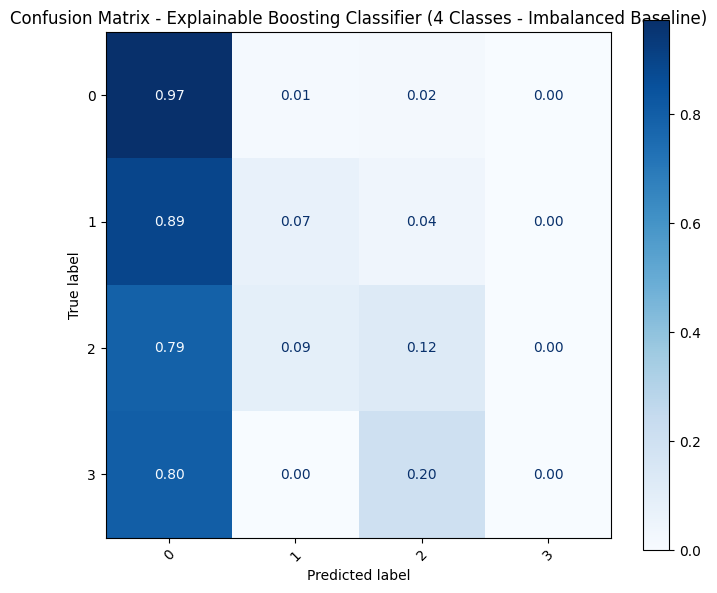

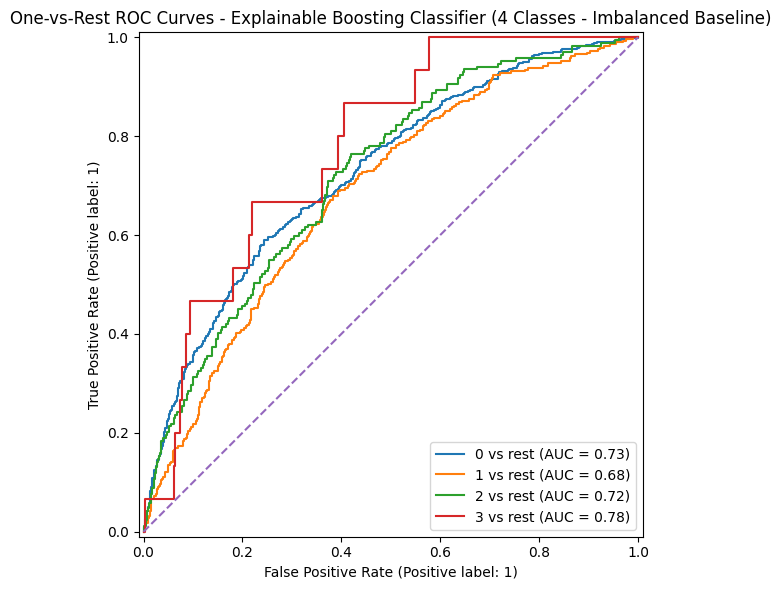

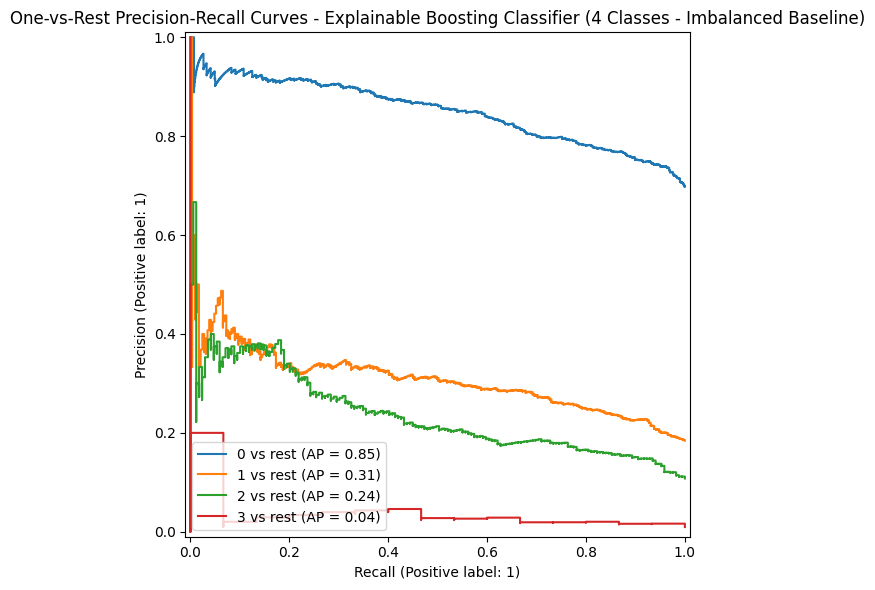


Classification report - Explainable Boosting Classifier (4 Classes - Imbalanced Baseline)


,precision,recall,f1-score,support
0,0.725971,0.972603,0.831382,1095.000000
1,0.428571,0.072664,0.124260,289.000000
2,0.403846,0.124260,0.190045,169.000000
3,0.000000,0.000000,0.000000,15.000000
accuracy,0.705995,0.705995,0.705995,0.705995
macro avg,0.389597,0.292382,0.286422,1568.000000
weighted avg,0.629493,0.705995,0.623974,1568.000000


In [15]:
import numpy as np
import pandas as pd
from collections import Counter
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# =========================================================================
# 1. PREPARAZIONE DATI (4 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: DATA PREPARATION (4 CLASSES) ===")

# Allineiamo le classi a [0, 1, 2, 3] per coerenza metodologica con gli altri modelli
if df['sii'].min() == 1:
    y_clean_4classes = df['sii'] - 1
else:
    y_clean_4classes = df['sii']

print("Distribuzione originale delle 4 classi per EBM:")
print(Counter(y_clean_4classes))

X = df.drop(columns=['sii'])
# Train/Test Split stratificato sulle 4 classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_4classes, test_size=0.2, random_state=42, stratify=y_clean_4classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_ebm = {
    # Tasso di apprendimento per i round di boosting additivo
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    
    # Numero di bin (intervalli) per la discretizzazione delle feature continue
    'max_bins': [32, 64, 128, 256],
    
    # Numero di bin utilizzati per modellare le interazioni tra coppie di feature
    'max_interaction_bins': [16, 32, 64],
    
    # Numero di interazioni di secondo ordine (a coppie) da estrarre automaticamente
    'interactions': [0],
    
    # Numero di iterazioni esterne di bagging per stabilizzare l'addestramento
    'outer_bags': [4, 8, 16],
    
    # Numero di iterazioni interne di bagging per ridurre la varianza di ogni round
    'inner_bags': [0]
}

# Modello base EBM configurato per sfruttare tutti i core della CPU (n_jobs=-1)
ebm_base = ExplainableBoostingClassifier(
    n_jobs=-1,
    random_state=42,
    feature_names=X_train.columns.tolist() # Passiamo i nomi delle feature per interpretabilità completa
)

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (3-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (EBM IMBALANCED) ===")

random_search_ebm = RandomizedSearchCV(
    estimator=ebm_base,
    param_distributions=param_dist_ebm,
    n_iter=20,                     # 20 combinazioni stocastiche nello spazio dei parametri
    cv=3,                          # 3-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizziamo per la balanced accuracy per contrastare lo sbilanciamento
    n_jobs=1,                      # Il multi-core è già gestito internamente da EBM
    random_state=42,
    verbose=1
)

# Avvio del fitting direttamente sui dati originali sbilanciati
random_search_ebm.fit(X_train, y_train)

# Estrazione del modello migliore
best_ebm = random_search_ebm.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_ebm.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_ebm.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Passiamo l'oggetto EBM ottimizzato alla funzione per generare i report e la matrice
results, report_df = evaluate_classifier(
    model=best_ebm,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="Explainable Boosting Classifier (4 Classes - Imbalanced Baseline)",
    normalize_cm="true"
)

In [16]:
# Generiamo la spiegazione globale (Feature Importance ed effetti)
ebm_global = best_ebm.explain_global(name='EBM Global Explanation (4 Classes)')

# visualizziamo la dashboard interattiva:
from interpret import show
show(ebm_global)

<!-- http://127.0.0.1:7001/2215910507776/ -->

## 4 classes, balanced

=== STEP 1: DATA PREPARATION (4 CLASSES) ===
Distribuzione originale delle 4 classi per EBM:
Counter({0: 5476, 1: 1444, 2: 846, 3: 73})

=== STEP 2: HYPERPARAMETER TUNING (EBM BALANCED ADASYN + ENN) ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'enn__n_neighbors': 3, 'enn__kind_sel': 'mode', 'ebm__outer_bags': 4, 'ebm__max_interaction_bins': 16, 'ebm__max_bins': 64, 'ebm__learning_rate': 0.1, 'ebm__interactions': 0, 'ebm__inner_bags': 0, 'adasyn__n_neighbors': 7}
Best Balanced Accuracy Score (CV): 0.3514

=== STEP 3: FINAL EVALUATION ON TEST SET ===


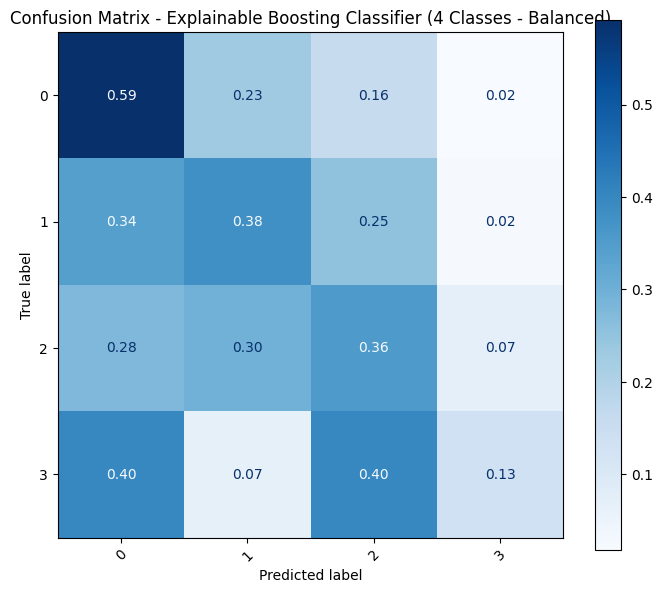

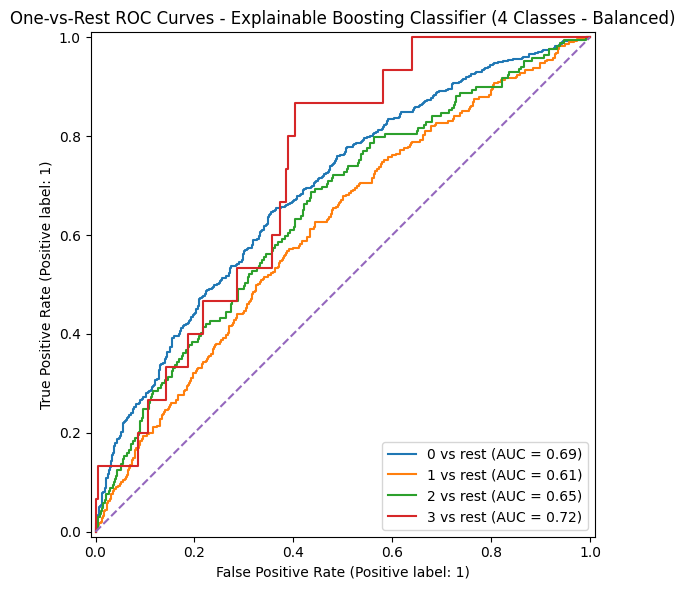

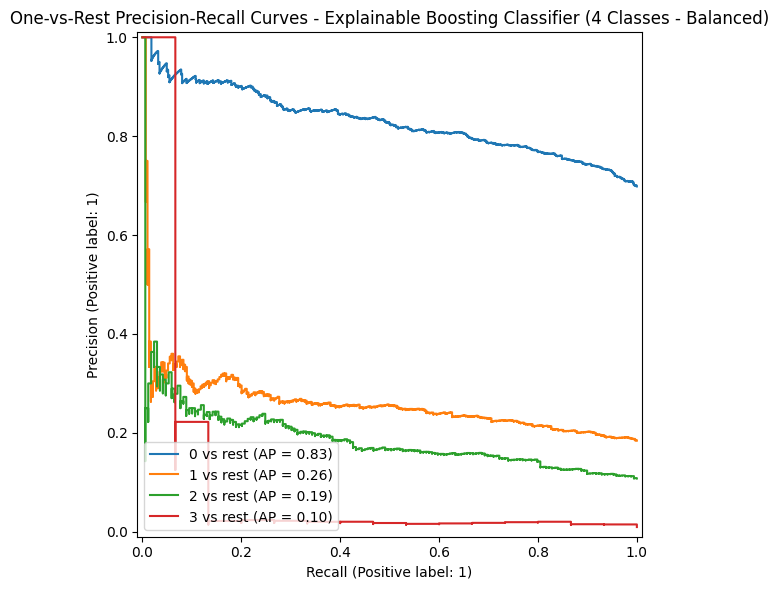


Classification report - Explainable Boosting Classifier (4 Classes - Balanced)


,precision,recall,f1-score,support
0,0.810000,0.591781,0.683905,1095.000000
1,0.265700,0.380623,0.312945,289.000000
2,0.191693,0.355030,0.248963,169.000000
3,0.048780,0.133333,0.071429,15.000000
accuracy,0.522959,0.522959,0.522959,0.522959
macro avg,0.329044,0.365192,0.329310,1568.000000
weighted avg,0.635756,0.522959,0.562795,1568.000000


In [20]:
import numpy as np
import pandas as pd
from collections import Counter
from interpret.glassbox import ExplainableBoostingClassifier      
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# ---> IMPORT MANCANTI AGGIUNTI <---
from imblearn.over_sampling import ADASYN                         
from imblearn.under_sampling import EditedNearestNeighbours        
from imblearn.pipeline import Pipeline as ImbPipeline              

# =========================================================================
# 1. PREPARAZIONE DATI (4 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: DATA PREPARATION (4 CLASSES) ===")

# Allineiamo le classi a [0, 1, 2, 3] per coerenza metodologica
if df['sii'].min() == 1:
    y_clean_4classes = df['sii'] - 1
else:
    y_clean_4classes = df['sii']

print("Distribuzione originale delle 4 classi per EBM:")
print(Counter(y_clean_4classes))

X = df.drop(columns=['sii'])

# Train/Test Split stratificato sulle 4 classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_4classes, test_size=0.2, random_state=42, stratify=y_clean_4classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_ebm = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],

    # CORRETTO TYPO: 2 underscore invece di 3
    'ebm__learning_rate': [0.01, 0.02, 0.05, 0.1],
    
    # Numero di bin (intervalli) per la discretizzazione delle feature continue
    'ebm__max_bins': [32, 64, 128, 256],
    
    # Numero di bin utilizzati per modellare le interazioni tra coppie di feature
    'ebm__max_interaction_bins': [16, 32, 64],
    
    # Numero di interazioni di secondo ordine (a coppie) da estrarre automaticamente
    'ebm__interactions': [0], # Disattivate per velocizzare il tuning
    
    # Numero di iterazioni esterne di bagging per stabilizzare l'addestramento
    'ebm__outer_bags': [4, 8, 16],
    
    # Numero di iterazioni interne di bagging per ridurre la varianza di ogni round
    'ebm__inner_bags': [0]
}

# definizione dei ricampionatori per la pipeline ibrida
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Modello base EBM configurato per sfruttare tutti i core della CPU (n_jobs=-1)
ebm_base = ExplainableBoostingClassifier(
    n_jobs=-1,
    random_state=42,
    feature_names=X_train.columns.tolist() # Nomi delle feature per XAI
)

# pipeline sequenziale: ADASYN genera i sintetici -> ENN pulisce i confini -> EBM studia
pipeline_ebm_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), # Fase 1: Oversampling adattivo
    ('enn', enn_sampler),       # Fase 2: Pulizia delle sovrapposizioni
    ('ebm', ebm_base)           # Fase 3: Modellazione additiva spiegabile
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (3-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (EBM BALANCED ADASYN + ENN) ===")

random_search_ebm = RandomizedSearchCV(
    estimator=pipeline_ebm_hybrid,
    param_distributions=param_dist_ebm,
    n_iter=20,                     # 20 combinazioni stocastiche
    cv=3,                          # 3-Fold Cross-Validation
    scoring='balanced_accuracy',   # Ottimizziamo per la balanced accuracy
    n_jobs=1,                      # Manteniamo 1, EBM sfrutta il multi-core in autonomia
    random_state=42,
    verbose=1
)

# Avvio del fitting
random_search_ebm.fit(X_train, y_train)

# Estrazione del modello migliore
best_pipeline_ebm = random_search_ebm.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_ebm.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_ebm.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Passiamo la pipeline ottimizzata alla funzione di valutazione
results, report_df = evaluate_classifier(
    model=best_pipeline_ebm,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="Explainable Boosting Classifier (4 Classes - Balanced)",
    normalize_cm="true"
)

In [21]:
# Estraiamo il modello EBM addestrato dalla pipeline vincente
trained_ebm = best_pipeline_ebm.named_steps['ebm']

# Generiamo la spiegazione globale (Feature Importance ed effetti)
ebm_global = trained_ebm.explain_global(name='EBM Global Explanation')

# visualizziamo la dashboard interattiva:
from interpret import show
show(ebm_global)

<!-- http://127.0.0.1:7001/2215869328240/ -->

## 3 classes, balanced

=== STEP 1: CLASS AGGREGATION & ALIGNMENT ===
Distribuzione delle 3 macro-classi (0, 1, 2):
Counter({0: 5476, 1: 1444, 2: 919})

=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + EBM) ===
Nota: EBM è un modello molto rigoroso, il tuning potrebbe richiedere un po' più di tempo.
Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'enn__n_neighbors': 7, 'enn__kind_sel': 'mode', 'ebm__outer_bags': 8, 'ebm__max_interaction_bins': 32, 'ebm__max_bins': 256, 'ebm__learning_rate': 0.02, 'ebm__interactions': 0, 'ebm__inner_bags': 0, 'adasyn__n_neighbors': 7}
Best Balanced Accuracy Score (CV): 0.4680

=== STEP 3: FINAL EVALUATION ON TEST SET ===


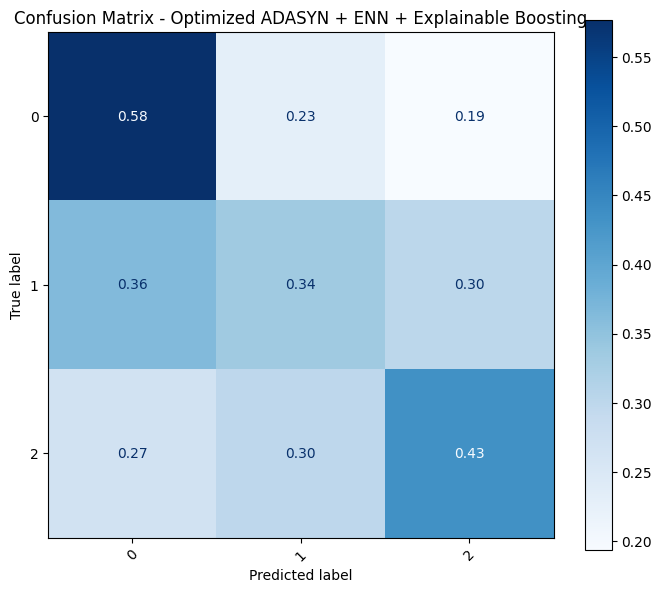

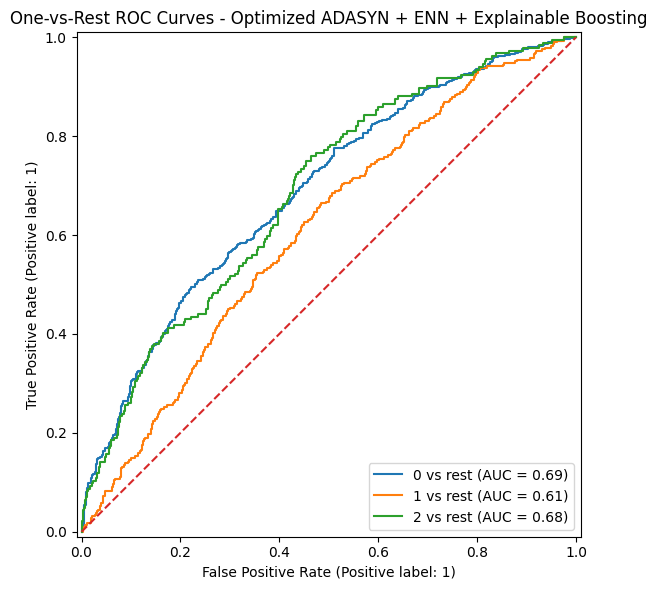

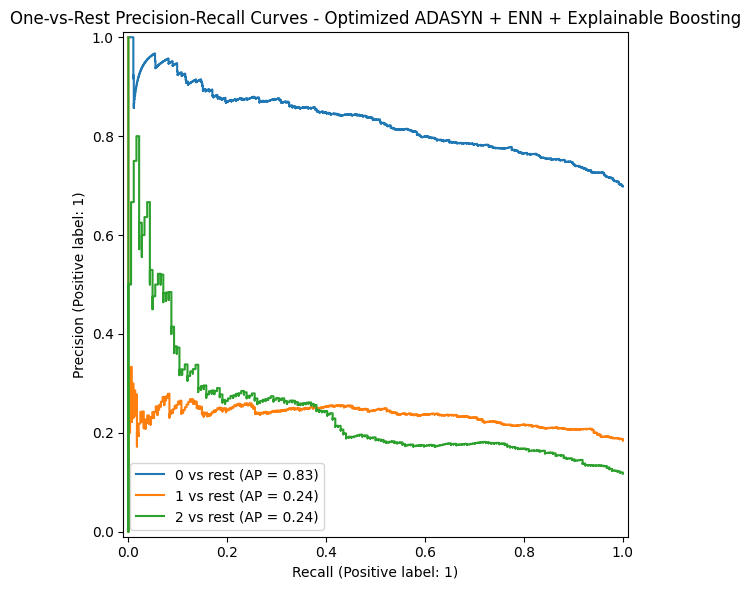


Classification report - Optimized ADASYN + ENN + Explainable Boosting


,precision,recall,f1-score,support
0,0.804071,0.577169,0.671983,1095.000000
1,0.240695,0.335640,0.280347,289.000000
2,0.211082,0.434783,0.284192,184.000000
accuracy,0.515944,0.515944,0.515944,0.515944
macro avg,0.418616,0.449197,0.412174,1568.000000
weighted avg,0.630649,0.515944,0.554294,1568.000000


In [14]:
import numpy as np
import pandas as pd
from collections import Counter
from interpret.glassbox import ExplainableBoostingClassifier      
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.over_sampling import ADASYN                         
from imblearn.under_sampling import EditedNearestNeighbours        
from imblearn.pipeline import Pipeline as ImbPipeline  
from evaluate_classifier import evaluate_classifier 

# =========================================================================
# 1. ACCORPAMENTO CLINICO E PREPARAZIONE DATI (3 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: CLASS AGGREGATION & ALIGNMENT ===")

# Uniamo la classe 3 e 4 sotto il tag 2
y_clean_3classes = df['sii'].replace({3: 2})

# Manteniamo la notazione [0, 1, 2] usata per gli altri modelli di Boosting
if y_clean_3classes.min() == 1:
    y_clean_3classes = y_clean_3classes - 1

print("Distribuzione delle 3 macro-classi (0, 1, 2):")
print(Counter(y_clean_3classes))

# Train/Test Split stratificato sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefisso 'ebm__')
# =========================================================================
param_dist_hybrid_ebm = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri specifici dell'Explainable Boosting Classifier (prefisso 'ebm__')
    'ebm__learning_rate': [0.01, 0.02, 0.05, 0.1], # Passo di aggiornamento dei round di boosting
    'ebm__max_bins': [32, 64, 128, 256],           # Numero di bin per discretizzare le feature numeriche
    'ebm__max_interaction_bins': [16, 32, 64],     # Numero di bin per le interazioni tra coppie di feature
    'ebm__interactions': [0],           # Numero di interazioni a coppie da considerare (0 disattiva le interazioni)
    'ebm__outer_bags': [4, 8, 16],                 # Numero di bag esterni per stabilizzare i gradienti
    'ebm__inner_bags': [0]                   # (0 è il default, riduce la varianza ma è lentissimo)
}

# =========================================================================
# 3. COSTRUZIONE DELLA PIPELINE IBRIDA PROTETTA
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

# Modello base EBM. 
# n_jobs=-1 permette di parallelizzare la costruzione dei bin su tutti i core della CPU
ebm_base = ExplainableBoostingClassifier(
    n_jobs=-1,
    random_state=42,
    feature_names=X_train.columns.tolist()
)

# Pipeline sequenziale: previene il Data Leakage durante la Cross-Validation
pipeline_ebm_hybrid = ImbPipeline([
    ('adasyn', adasyn_sampler), # Fase 1: Oversampling adattivo
    ('enn', enn_sampler),       # Fase 2: Pulizia delle sovrapposizioni
    ('ebm', ebm_base)           # Fase 3: Modellazione additiva spiegabile
])

# =========================================================================
# 4. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + EBM) ===")
print("Nota: EBM è un modello molto rigoroso, il tuning potrebbe richiedere un po' più di tempo.")

random_search_hybrid_ebm = RandomizedSearchCV(
    estimator=pipeline_ebm_hybrid,
    param_distributions=param_dist_hybrid_ebm,
    n_iter=20,                     # Ridotto leggermente a 20 per compensare la complessità computazionale
    cv=3,                          
    scoring='balanced_accuracy',   # Ottimizzazione coerente focalizzata sulla Recall macro
    n_jobs=1,                      # Il parallelismo interno è delegato ad EBM
    random_state=42,
    verbose=1
)

# Il fit applica l'intera catena fold per fold
random_search_hybrid_ebm.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_ebm = random_search_hybrid_ebm.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_ebm.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_ebm.best_score_:.4f}\n")

# =========================================================================
# 5. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("=== STEP 3: FINAL EVALUATION ON TEST SET ===")

# Passiamo la pipeline ottimizzata direttamente alla funzione originale
results, report_df = evaluate_classifier(
    model=best_pipeline_ebm,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi (immacolato)
    y_test=y_test,
    model_name="Optimized ADASYN + ENN + Explainable Boosting",
    normalize_cm="true"
)

In [17]:
# Estraiamo il modello EBM addestrato dalla pipeline vincente
trained_ebm = best_pipeline_ebm.named_steps['ebm']

# Generiamo la spiegazione globale (Feature Importance ed effetti)
ebm_global = trained_ebm.explain_global(name='EBM Global Explanation')

# visualizziamo la dashboard interattiva:
from interpret import show
show(ebm_global)

<!-- http://127.0.0.1:7001/2215918727584/ -->